# EfficientNet-B3 Experiment Notebook

This notebook contains the full experimentation process for the EfficientNet-B3 model, including baseline training, tuning attempts, intermediate comparisons, and final model selection.

Some outputs may reflect the original local runtime environment used during experimentation. This notebook is included as experiment history rather than the primary rerunnable notebook.

**GitHub note:** This notebook is included as experiment history. For a polished final summary, see `notebooks/final/EfficientNetB3_FINAL.ipynb`. For a cleaner rerun/evaluation workflow, see `notebooks/reproducibility/EfficientNet_B3_Reproducibility.ipynb`.

# EfficientNet-B3 Experiments

This notebook trains and evaluates EfficientNet-B3 from scratch for image-level real vs fake face classification.

Primary dataset:
- Kaggle 140k Real and Fake Faces

Model:
- EfficientNet-B3
- trained from scratch
- binary classification: fake vs real

Primary tuning metric:
- validation F1-score

Important rule:
- the held-out test split is used only after tuning is complete

## EfficientNet-B3 Restart Checklist

After shutting down the PC or restarting the kernel, rerun the setup and definition cells before continuing with new experiments.

### Rerun these sections in order:
1. Imports
2. Device Setup
3. Project Paths and Dataset Paths
4. Data Transforms / Augmentation Definitions
5. Dataset and Dataloader setup
6. Model Definition
7. Metric Function
8. Training Function
9. Validation Function
10. Experiment Runner
11. plots_dir cell only if saving plots

### Do not rerun:
- old experiment run cells
- old plotting cells
- old evaluation cells

After the setup cells are loaded back into memory, continue with the next experiment section only.

## 1. Imports

In [1]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b3

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## 2. Device Setup

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce GTX 1080 Ti


## 3. Project Paths and Dataset Paths

In [3]:
project_root = Path.cwd().parent
results_dir = project_root / "results"
checkpoints_dir = project_root / "checkpoints"

results_dir.mkdir(exist_ok=True)
checkpoints_dir.mkdir(exist_ok=True)

data_root = Path.home() / "Desktop" / "real-vs-fake" / "real_vs_fake" / "real-vs-fake"

train_dir = data_root / "train"
val_dir = data_root / "valid"
test_dir = data_root / "test"

print("Project root:", project_root)
print("Train dir exists:", train_dir.exists())
print("Val dir exists:", val_dir.exists())
print("Test dir exists:", test_dir.exists())

Project root: C:\Users\Richa\anaconda_projects
Train dir exists: True
Val dir exists: True
Test dir exists: True


## 4. Transform Definitions

In [4]:
input_size = 224

light_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

medium_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

strong_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
    transforms.RandomRotation(15),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

val_transform = transforms.Compose([
    transforms.Resize((input_size, input_size)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

## 5. Dataloader Builder

In [5]:
batch_size = 8

def get_dataloaders(augmentation_name, batch_size=8):
    if augmentation_name == "light":
        train_transform = light_transform
    elif augmentation_name == "medium":
        train_transform = medium_transform
    elif augmentation_name == "strong":
        train_transform = strong_transform
    else:
        raise ValueError("Unsupported augmentation setting")

    train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
    val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=2
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2
    )

    return train_loader, val_loader

## 6. Dataset Sanity Check

In [6]:
train_loader, val_loader = get_dataloaders("light", batch_size=batch_size)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

train_dataset = datasets.ImageFolder(train_dir, transform=light_transform)
print("Classes:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)
print("Train size:", len(train_dataset))

Train batches: 12500
Val batches: 2500
Classes: ['fake', 'real']
Class to index: {'fake': 0, 'real': 1}
Train size: 100000


In [7]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)
print("First 8 labels:", labels[:8])

Image batch shape: torch.Size([8, 3, 224, 224])
Label batch shape: torch.Size([8])
Image dtype: torch.float32
Label dtype: torch.int64
First 8 labels: tensor([0, 0, 0, 0, 1, 0, 0, 0])


## 7. EfficientNet-B3 Model Definition

In [8]:
def get_efficientnet_b3(num_classes=2):
    model = efficientnet_b3(weights=None)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

In [9]:
model = get_efficientnet_b3(num_classes=2)
print(model.classifier)

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=2, bias=True)
)


## 8. Metric Functions

In [10]:
def compute_metrics(y_true, y_pred, y_prob):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics["roc_auc"] = float("nan")

    return metrics

## 9. Training Function

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    return epoch_loss

## 10. Validation Function

In [12]:
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            probs = torch.softmax(outputs, dim=1)[:, 1]
            preds = torch.argmax(outputs, dim=1)

            running_loss += loss.item() * images.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    metrics = compute_metrics(all_labels, all_preds, all_probs)
    metrics["loss"] = epoch_loss
    return metrics

## 11. Experiment Runner

In [13]:
def run_experiment(config):
    print(f"Starting run: {config['run_id']}")
    train_loader, val_loader = get_dataloaders(
        config["augmentation"],
        batch_size=config["batch_size"]
    )

    model = get_efficientnet_b3(num_classes=2).to(device)
    criterion = nn.CrossEntropyLoss()

    if config["optimizer"] == "Adam":
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )
    elif config["optimizer"] == "AdamW":
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config["lr"],
            weight_decay=config["weight_decay"]
        )
    elif config["optimizer"] == "SGD":
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=config["lr"],
            momentum=0.9,
            weight_decay=config["weight_decay"]
        )
    else:
        raise ValueError("Unsupported optimizer")

    scheduler = None
    if config.get("scheduler", "none") == "ReduceLROnPlateau":
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=1
        )

    best_val_f1 = -1.0
    best_epoch = -1
    patience_counter = 0
    history = []

    checkpoint_path = checkpoints_dir / f"{config['run_id']}_best.pth"
    start_time = time.time()

    for epoch in range(config["epochs"]):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_metrics = validate_one_epoch(model, val_loader, criterion, device)

        history_row = {
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"],
            "val_roc_auc": val_metrics["roc_auc"],
        }
        history.append(history_row)

        print(
            f"Epoch {epoch+1}/{config['epochs']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

        if scheduler is not None:
            scheduler.step(val_metrics["loss"])

        if np.isnan(train_loss) or np.isnan(val_metrics["loss"]):
            print("Stopping early: loss became NaN")
            break

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_epoch = epoch + 1
            patience_counter = 0

            torch.save({
                "run_id": config["run_id"],
                "epoch": best_epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "best_val_f1": best_val_f1,
                "config": config,
            }, checkpoint_path)
        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            print("Early stopping triggered.")
            break

    elapsed_minutes = (time.time() - start_time) / 60.0

    history_df = pd.DataFrame(history)
    best_row = history_df.loc[history_df["val_f1"].idxmax()].to_dict()

    run_result = {
        "run_id": config["run_id"],
        "model": "EfficientNet-B3",
        "run_type": config["run_type"],
        "batch_size": config["batch_size"],
        "epochs": config["epochs"],
        "optimizer": config["optimizer"],
        "learning_rate": config["lr"],
        "weight_decay": config["weight_decay"],
        "augmentation": config["augmentation"],
        "scheduler": config.get("scheduler", "none"),
        "val_loss": best_row["val_loss"],
        "val_accuracy": best_row["val_accuracy"],
        "val_precision": best_row["val_precision"],
        "val_recall": best_row["val_recall"],
        "val_f1": best_row["val_f1"],
        "val_roc_auc": best_row["val_roc_auc"],
        "best_epoch": int(best_row["epoch"]),
        "train_time_min": elapsed_minutes,
        "checkpoint_saved": str(checkpoint_path.name),
        "notes": config.get("notes", ""),
    }

    csv_path = results_dir / "efficientnet_experiment_log.csv"
    if csv_path.exists():
        df_existing = pd.read_csv(csv_path)
        df_new = pd.concat([df_existing, pd.DataFrame([run_result])], ignore_index=True)
    else:
        df_new = pd.DataFrame([run_result])

    df_new.to_csv(csv_path, index=False)

    print(f"Saved results to {csv_path}")
    print(f"Saved best checkpoint to {checkpoint_path}")

    return history_df, run_result

#### Plots_dir cells only if saving plots

In [5]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


## 12. Sanity Run Configuration

In [14]:
config = {
    "run_id": "E00",
    "run_type": "sanity",
    "epochs": 3,
    "patience": 2,
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "batch_size": 8,
    "scheduler": "none",
    "notes": "first EfficientNet-B3 sanity run",
}

## 13. Run Sanity Experiment

In [15]:
history_df, run_result = run_experiment(config)
history_df

Starting run: E00
Epoch 1/3 | Train Loss: 0.6939 | Val Loss: 0.6704 | Val F1: 0.5056
Epoch 2/3 | Train Loss: 0.6616 | Val Loss: 0.6405 | Val F1: 0.5355
Epoch 3/3 | Train Loss: 0.6515 | Val Loss: 0.6377 | Val F1: 0.5538
Saved results to C:\Users\Richa\anaconda_projects\results\efficientnet_experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\E00_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.693910,0.670386,0.59630,0.652133,0.4128,0.505573,0.612227
1,2,0.661625,0.640487,0.63415,0.733264,0.4217,0.535458,0.654939
2,3,0.651539,0.637668,0.65120,0.768371,0.4329,0.553793,0.678459


In [16]:
run_result

{'run_id': 'E00',
 'model': 'EfficientNet-B3',
 'run_type': 'sanity',
 'batch_size': 8,
 'epochs': 3,
 'optimizer': 'Adam',
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'scheduler': 'none',
 'val_loss': 0.6376682905197144,
 'val_accuracy': 0.6512,
 'val_precision': 0.768370607028754,
 'val_recall': 0.4329,
 'val_f1': 0.5537930152232314,
 'val_roc_auc': 0.678458725,
 'best_epoch': 3,
 'train_time_min': 67.14190242290496,
 'checkpoint_saved': 'E00_best.pth',
 'notes': 'first EfficientNet-B3 sanity run'}

### EfficientNet-B3 Sanity Run Interpretation

The sanity run confirmed that the EfficientNet-B3 training pipeline works correctly. Training and validation loss decreased over 3 epochs, while validation accuracy and F1-score improved modestly. This indicates that the model, dataloaders, metric functions, and checkpoint-saving pipeline are functioning as expected.

### 13.1 Save E00 History

In [17]:
history_path = results_dir / "E00_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\E00_history.csv


In [18]:
checkpoint_path = checkpoints_dir / "E00_best.pth"
print("Checkpoint exists:", checkpoint_path.exists())
print("Checkpoint path:", checkpoint_path)

Checkpoint exists: True
Checkpoint path: C:\Users\Richa\anaconda_projects\checkpoints\E00_best.pth


### 13.2 Save E00 Plots

In [19]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


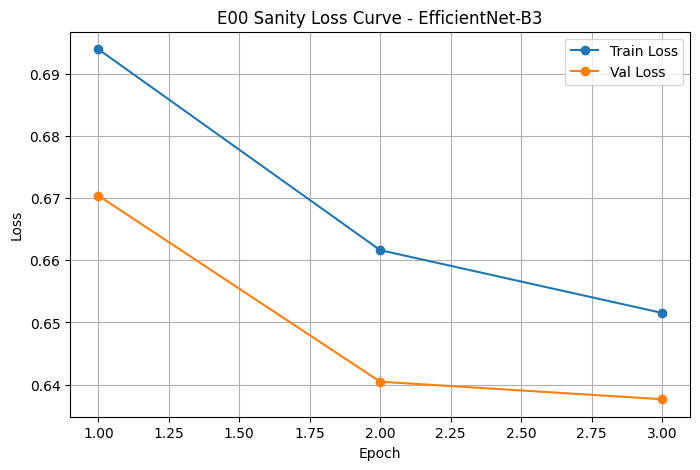

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E00 Sanity Loss Curve - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E00_loss_curve.png", bbox_inches="tight")
plt.show()

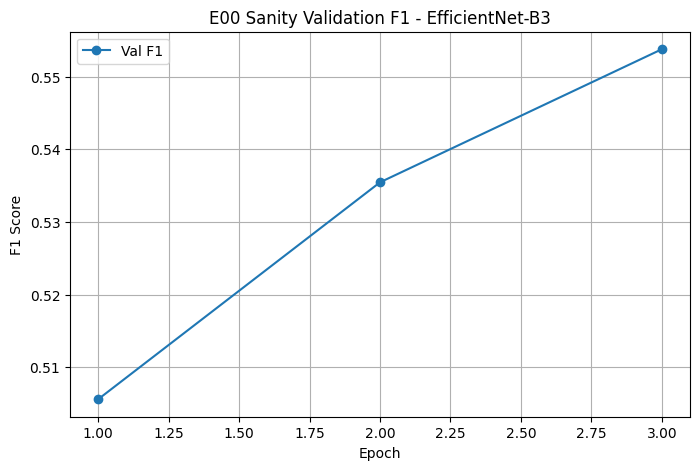

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("E00 Sanity Validation F1 - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E00_val_f1.png", bbox_inches="tight")
plt.show()

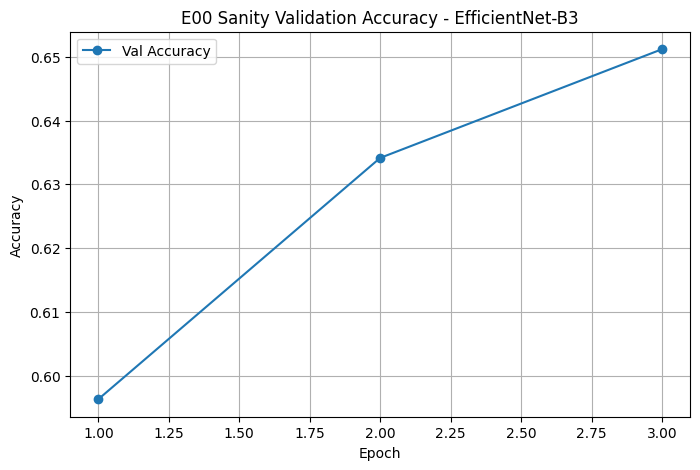

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E00 Sanity Validation Accuracy - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E00_val_accuracy.png", bbox_inches="tight")
plt.show()

## 14. Run Baseline Experiment

### 14.1 E01 Baseline

In [23]:
config = {
    "run_id": "E01",
    "run_type": "baseline",
    "epochs": 10,
    "patience": 3,
    "optimizer": "Adam",
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "batch_size": 8,
    "scheduler": "none",
    "notes": "official EfficientNet-B3 baseline",
}

In [24]:
history_df, run_result = run_experiment(config)
history_df

Starting run: E01
Epoch 1/10 | Train Loss: 0.6906 | Val Loss: 0.6573 | Val F1: 0.4942
Epoch 2/10 | Train Loss: 0.5676 | Val Loss: 0.5367 | Val F1: 0.6668
Epoch 3/10 | Train Loss: 0.4435 | Val Loss: 0.3450 | Val F1: 0.8456
Epoch 4/10 | Train Loss: 0.3717 | Val Loss: 0.3107 | Val F1: 0.8574
Epoch 5/10 | Train Loss: 0.3015 | Val Loss: 0.2390 | Val F1: 0.9055
Epoch 6/10 | Train Loss: 0.2546 | Val Loss: 0.2112 | Val F1: 0.9083
Epoch 7/10 | Train Loss: 0.2168 | Val Loss: 0.1777 | Val F1: 0.9329
Epoch 8/10 | Train Loss: 0.1905 | Val Loss: 0.1493 | Val F1: 0.9411
Epoch 9/10 | Train Loss: 0.1755 | Val Loss: 0.1735 | Val F1: 0.9347
Epoch 10/10 | Train Loss: 0.1647 | Val Loss: 0.1282 | Val F1: 0.9495
Saved results to C:\Users\Richa\anaconda_projects\results\efficientnet_experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\E01_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.690595,0.657272,0.61430,0.717714,0.3768,0.494164,0.687173
1,2,0.567596,0.536714,0.73280,0.885558,0.5347,0.666791,0.877779
2,3,0.443463,0.344972,0.84885,0.864182,0.8278,0.845600,0.928174
3,4,0.371701,0.310684,0.86580,0.914833,0.8067,0.857371,0.950540
4,5,0.301457,0.239041,0.90160,0.870685,0.9433,0.905539,0.968793
5,6,0.254566,0.211157,0.91110,0.937527,0.8809,0.908332,0.975426
6,7,0.216778,0.177736,0.93150,0.914267,0.9523,0.932896,0.982998
7,8,0.190497,0.149286,0.94120,0.942261,0.9400,0.941129,0.986435
8,9,0.175530,0.173517,0.93295,0.911354,0.9592,0.934665,0.983572
9,10,0.164674,0.128220,0.94985,0.956561,0.9425,0.949479,0.990644


In [25]:
run_result

{'run_id': 'E01',
 'model': 'EfficientNet-B3',
 'run_type': 'baseline',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'Adam',
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'scheduler': 'none',
 'val_loss': 0.12821999578624962,
 'val_accuracy': 0.94985,
 'val_precision': 0.9565614533644575,
 'val_recall': 0.9425,
 'val_f1': 0.9494786682113534,
 'val_roc_auc': 0.99064434,
 'best_epoch': 10,
 'train_time_min': 223.64866660435993,
 'checkpoint_saved': 'E01_best.pth',
 'notes': 'official EfficientNet-B3 baseline'}

### 14.2 Save E01 History and Plots

In [26]:
history_path = results_dir / "E01_baseline_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\E01_baseline_history.csv


In [27]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


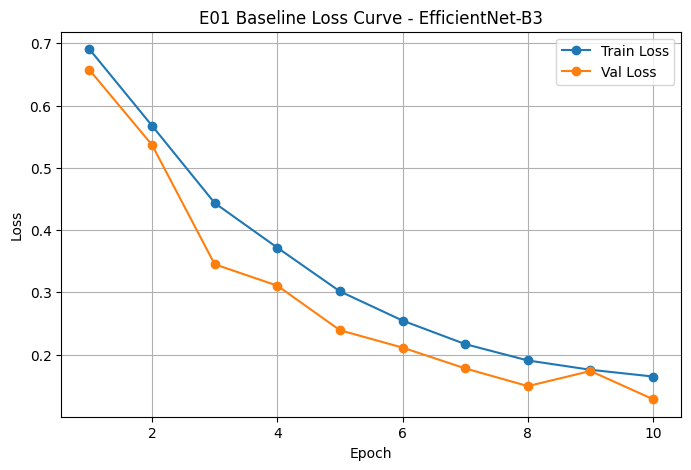

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E01 Baseline Loss Curve - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E01_baseline_loss_curve.png", bbox_inches="tight")
plt.show()

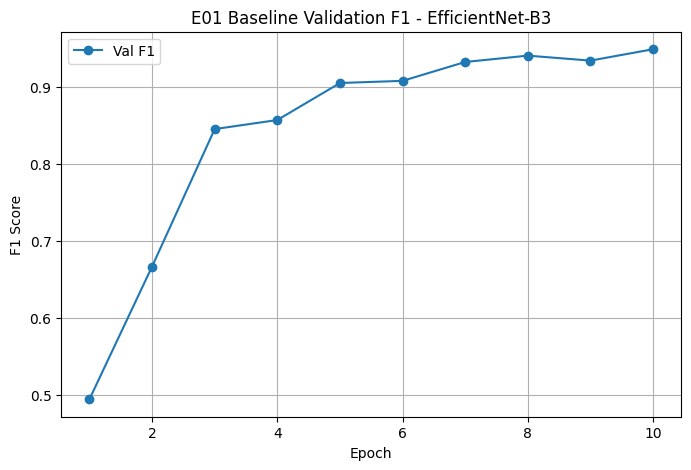

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("E01 Baseline Validation F1 - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E01_baseline_val_f1.png", bbox_inches="tight")
plt.show()

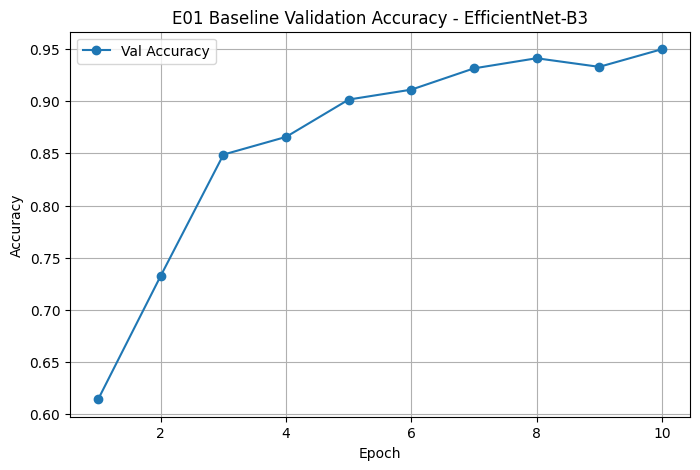

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E01 Baseline Validation Accuracy - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E01_baseline_val_accuracy.png", bbox_inches="tight")
plt.show()

## 15. Learning Rate Tuning

### 15.1 E02 Learning Rate = 1e-4

In [31]:
config = {
    "run_id": "E02",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "Adam",
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "batch_size": 8,
    "scheduler": "none",
    "notes": "learning rate tuning: lr=1e-4",
}

In [32]:
history_df, run_result = run_experiment(config)
history_df

Starting run: E02
Epoch 1/10 | Train Loss: 0.5792 | Val Loss: 0.4127 | Val F1: 0.8050
Epoch 2/10 | Train Loss: 0.3624 | Val Loss: 0.3078 | Val F1: 0.8564
Epoch 3/10 | Train Loss: 0.2389 | Val Loss: 0.1687 | Val F1: 0.9346
Epoch 4/10 | Train Loss: 0.1735 | Val Loss: 0.1606 | Val F1: 0.9322
Epoch 5/10 | Train Loss: 0.1343 | Val Loss: 0.1300 | Val F1: 0.9470
Epoch 6/10 | Train Loss: 0.1112 | Val Loss: 0.1110 | Val F1: 0.9590
Epoch 7/10 | Train Loss: 0.0914 | Val Loss: 0.0916 | Val F1: 0.9660
Epoch 8/10 | Train Loss: 0.0787 | Val Loss: 0.0792 | Val F1: 0.9697
Epoch 9/10 | Train Loss: 0.0692 | Val Loss: 0.0746 | Val F1: 0.9722
Epoch 10/10 | Train Loss: 0.0616 | Val Loss: 0.0885 | Val F1: 0.9641
Saved results to C:\Users\Richa\anaconda_projects\results\efficientnet_experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\E02_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.579172,0.412664,0.81415,0.846859,0.7670,0.804954,0.902964
1,2,0.362388,0.307847,0.86815,0.940318,0.7862,0.856380,0.962364
2,3,0.238861,0.168705,0.93405,0.926501,0.9429,0.934629,0.982977
3,4,0.173530,0.160640,0.93425,0.962116,0.9041,0.932206,0.987251
4,5,0.134286,0.130008,0.94815,0.969218,0.9257,0.946959,0.991786
5,6,0.111230,0.111036,0.95790,0.933946,0.9855,0.959031,0.994344
6,7,0.091405,0.091573,0.96605,0.968722,0.9632,0.965953,0.994989
7,8,0.078670,0.079186,0.96990,0.975415,0.9641,0.969724,0.996020
8,9,0.069198,0.074576,0.97185,0.960297,0.9844,0.972199,0.996586
9,10,0.061600,0.088536,0.96495,0.988034,0.9413,0.964101,0.997020


In [33]:
run_result

{'run_id': 'E02',
 'model': 'EfficientNet-B3',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'Adam',
 'learning_rate': 0.0001,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'scheduler': 'none',
 'val_loss': 0.07457618770444532,
 'val_accuracy': 0.97185,
 'val_precision': 0.9602965564335186,
 'val_recall': 0.9844,
 'val_f1': 0.9721989037578391,
 'val_roc_auc': 0.99658557,
 'best_epoch': 9,
 'train_time_min': 224.0412298043569,
 'checkpoint_saved': 'E02_best.pth',
 'notes': 'learning rate tuning: lr=1e-4'}

### 15.1.1 Save E02 History and Plots

In [34]:
history_path = results_dir / "E02_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\E02_history.csv


In [35]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


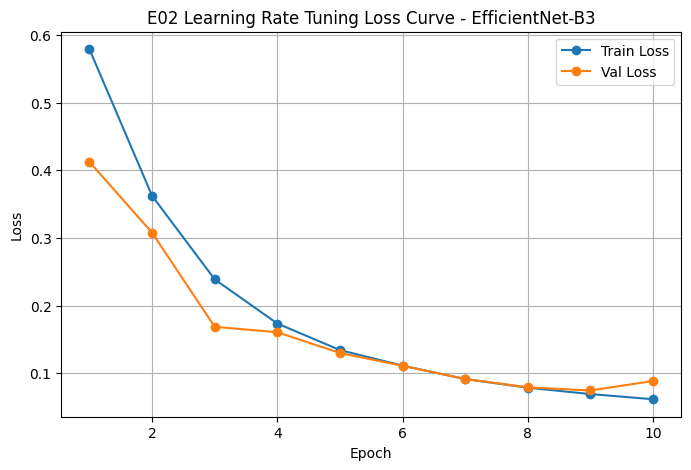

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E02 Learning Rate Tuning Loss Curve - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E02_loss_curve.png", bbox_inches="tight")
plt.show()

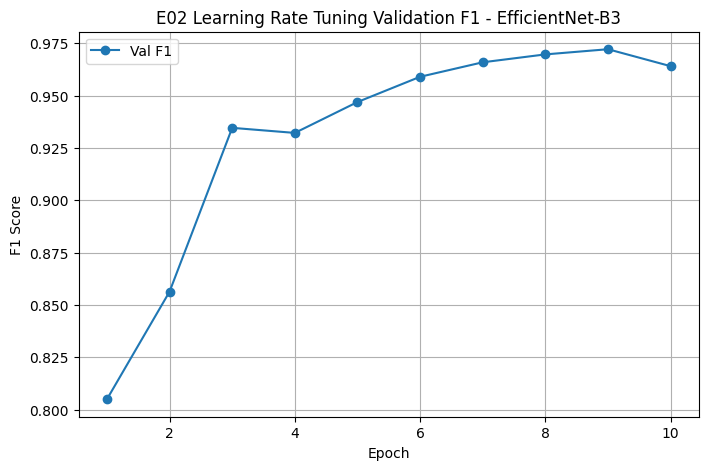

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("E02 Learning Rate Tuning Validation F1 - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E02_val_f1.png", bbox_inches="tight")
plt.show()

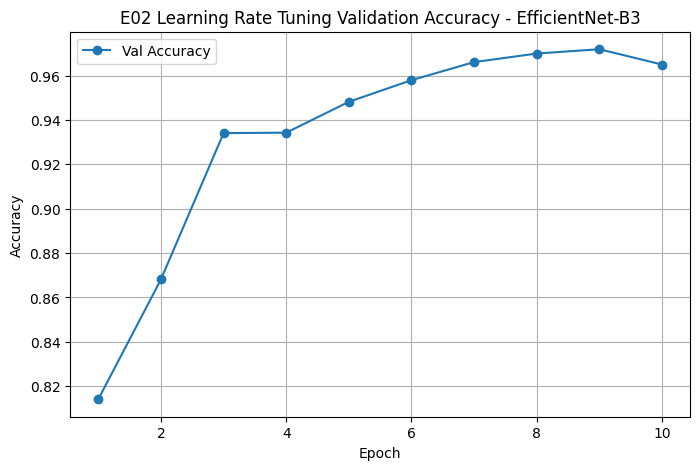

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E02 Learning Rate Tuning Validation Accuracy - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E02_val_accuracy.png", bbox_inches="tight")
plt.show()

### 15.2 E03 Learning Rate = 3e-4

In [15]:
config = {
    "run_id": "E03",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "Adam",
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "batch_size": 8,
    "scheduler": "none",
    "notes": "learning rate tuning: lr=3e-4",
}

In [16]:
history_df, run_result = run_experiment(config)
history_df

Starting run: E03
Epoch 1/10 | Train Loss: 0.5582 | Val Loss: 0.3718 | Val F1: 0.8390
Epoch 2/10 | Train Loss: 0.3260 | Val Loss: 0.2116 | Val F1: 0.9185
Epoch 3/10 | Train Loss: 0.2110 | Val Loss: 0.1530 | Val F1: 0.9421
Epoch 4/10 | Train Loss: 0.1538 | Val Loss: 0.2098 | Val F1: 0.9178
Epoch 5/10 | Train Loss: 0.1208 | Val Loss: 0.1504 | Val F1: 0.9417
Epoch 6/10 | Train Loss: 0.0973 | Val Loss: 0.0812 | Val F1: 0.9678
Epoch 7/10 | Train Loss: 0.0808 | Val Loss: 0.0621 | Val F1: 0.9765
Epoch 8/10 | Train Loss: 0.0699 | Val Loss: 0.0799 | Val F1: 0.9697
Epoch 9/10 | Train Loss: 0.0632 | Val Loss: 0.0551 | Val F1: 0.9790
Epoch 10/10 | Train Loss: 0.0556 | Val Loss: 0.0649 | Val F1: 0.9768
Saved results to C:\Users\Richa\anaconda_projects\results\efficientnet_experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\E03_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.558249,0.371773,0.83945,0.841190,0.8369,0.839040,0.917455
1,2,0.326039,0.211620,0.91635,0.895357,0.9429,0.918513,0.973878
2,3,0.211049,0.153011,0.94040,0.916336,0.9693,0.942074,0.986607
3,4,0.153770,0.209791,0.91080,0.851051,0.9959,0.917796,0.991571
4,5,0.120795,0.150375,0.93865,0.896645,0.9916,0.941735,0.992791
5,6,0.097307,0.081233,0.96795,0.970917,0.9648,0.967849,0.995891
6,7,0.080802,0.062076,0.97650,0.976214,0.9768,0.976507,0.997596
7,8,0.069918,0.079871,0.97030,0.990202,0.9500,0.969685,0.997822
8,9,0.063181,0.055123,0.97880,0.967669,0.9907,0.979049,0.998490
9,10,0.055592,0.064938,0.97650,0.962801,0.9913,0.976843,0.997962


In [18]:
run_result

{'run_id': 'E03',
 'model': 'EfficientNet-B3',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'Adam',
 'learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'scheduler': 'none',
 'val_loss': 0.055122811224701584,
 'val_accuracy': 0.9788,
 'val_precision': 0.9676694666927135,
 'val_recall': 0.9907,
 'val_f1': 0.9790493131732385,
 'val_roc_auc': 0.99848966,
 'best_epoch': 9,
 'train_time_min': 203.3540765484174,
 'checkpoint_saved': 'E03_best.pth',
 'notes': 'learning rate tuning: lr=3e-4'}

### 15.2.1 Save E03 History and Plots

In [19]:
history_path = results_dir / "E03_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\E03_history.csv


In [20]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


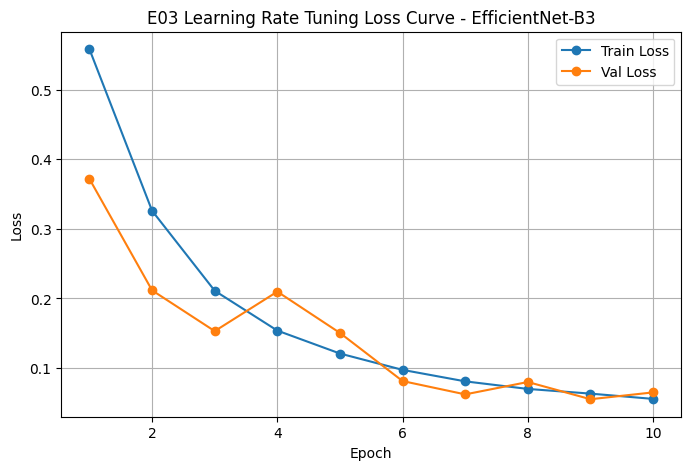

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E03 Learning Rate Tuning Loss Curve - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E03_loss_curve.png", bbox_inches="tight")
plt.show()

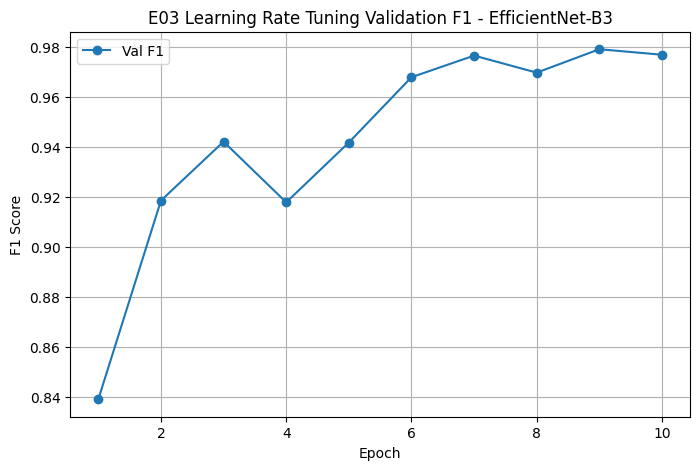

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("E03 Learning Rate Tuning Validation F1 - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E03_val_f1.png", bbox_inches="tight")
plt.show()

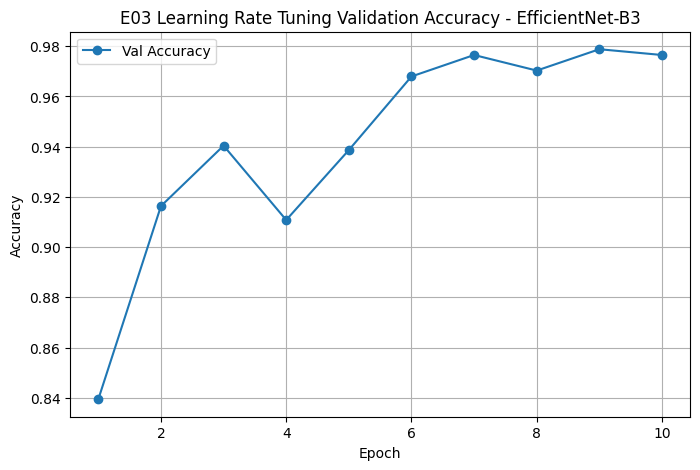

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E03 Learning Rate Tuning Validation Accuracy - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E03_val_accuracy.png", bbox_inches="tight")
plt.show()

For the best tuning rate, we got 3e-4

## 16. Optimizer Tuning

### 16.1 E04 Optimizer = AdamW

In [24]:
config = {
    "run_id": "E04",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "batch_size": 8,
    "scheduler": "none",
    "notes": "optimizer tuning: AdamW with best lr=3e-4",
}

In [25]:
history_df, run_result = run_experiment(config)
history_df

Starting run: E04
Epoch 1/10 | Train Loss: 0.6402 | Val Loss: 0.4607 | Val F1: 0.8014
Epoch 2/10 | Train Loss: 0.3907 | Val Loss: 0.2582 | Val F1: 0.8924
Epoch 3/10 | Train Loss: 0.2428 | Val Loss: 0.1690 | Val F1: 0.9290
Epoch 4/10 | Train Loss: 0.1644 | Val Loss: 0.1622 | Val F1: 0.9332
Epoch 5/10 | Train Loss: 0.1256 | Val Loss: 0.1053 | Val F1: 0.9599
Epoch 6/10 | Train Loss: 0.0986 | Val Loss: 0.0863 | Val F1: 0.9669
Epoch 7/10 | Train Loss: 0.0807 | Val Loss: 0.0731 | Val F1: 0.9738
Epoch 8/10 | Train Loss: 0.0705 | Val Loss: 0.0757 | Val F1: 0.9730
Epoch 9/10 | Train Loss: 0.0611 | Val Loss: 0.0879 | Val F1: 0.9659
Epoch 10/10 | Train Loss: 0.0518 | Val Loss: 0.0497 | Val F1: 0.9817
Saved results to C:\Users\Richa\anaconda_projects\results\efficientnet_experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\E04_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.640164,0.460707,0.78565,0.746569,0.8649,0.801390,0.867270
1,2,0.390717,0.258246,0.89640,0.927893,0.8596,0.892442,0.965567
2,3,0.242792,0.168960,0.93105,0.957445,0.9022,0.929002,0.984619
3,4,0.164430,0.162209,0.93450,0.952227,0.9149,0.933191,0.984971
4,5,0.125568,0.105345,0.95990,0.959074,0.9608,0.959936,0.992849
5,6,0.098628,0.086259,0.96735,0.981556,0.9526,0.966861,0.996148
6,7,0.080725,0.073072,0.97360,0.966142,0.9816,0.973810,0.996824
7,8,0.070500,0.075735,0.97325,0.983945,0.9622,0.972951,0.997196
8,9,0.061118,0.087889,0.96485,0.938579,0.9948,0.965872,0.997515
9,10,0.051825,0.049688,0.98170,0.979399,0.9841,0.981744,0.998385


In [26]:
run_result

{'run_id': 'E04',
 'model': 'EfficientNet-B3',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'scheduler': 'none',
 'val_loss': 0.04968753454765974,
 'val_accuracy': 0.9817,
 'val_precision': 0.9793988853503185,
 'val_recall': 0.9841,
 'val_f1': 0.9817438148443735,
 'val_roc_auc': 0.9983846000000002,
 'best_epoch': 10,
 'train_time_min': 202.5895538330078,
 'checkpoint_saved': 'E04_best.pth',
 'notes': 'optimizer tuning: AdamW with best lr=3e-4'}

In [28]:
excel_row_df = pd.DataFrame([{
    "Run ID": run_result["run_id"],
    "Run Type": run_result["run_type"],
    "Model": run_result["model"],
    "Input Size": 224,
    "Loss Function": "CrossEntropyLoss",
    "Epochs": run_result["epochs"],
    "Learning Rate": run_result["learning_rate"],
    "Optimizer": run_result["optimizer"],
    "Weight Decay": run_result["weight_decay"],
    "Augmentation": run_result["augmentation"],
    "Batch Size": run_result["batch_size"],
    "Scheduler": run_result["scheduler"],
    "Val Loss": run_result["val_loss"],
    "Val Accuracy": run_result["val_accuracy"],
    "Val Precision": run_result["val_precision"],
    "Val Recall": run_result["val_recall"],
    "Val F1": run_result["val_f1"],
    "Val ROC-AUC": run_result["val_roc_auc"],
    "Best Epoch": run_result["best_epoch"],
    "Train Time (min)": run_result["train_time_min"],
    "Checkpoint Saved": run_result["checkpoint_saved"],
    "Notes": run_result["notes"],
}])

excel_row_df

,Run ID,Run Type,Model,Input Size,Loss Function,Epochs,Learning Rate,Optimizer,Weight Decay,Augmentation,...,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Best Epoch,Train Time (min),Checkpoint Saved,Notes
0,E04,tuning,EfficientNet-B3,224,CrossEntropyLoss,10,0.0003,AdamW,0.0001,light,...,0.049688,0.9817,0.979399,0.9841,0.981744,0.998385,10,202.589554,E04_best.pth,optimizer tuning: AdamW with best lr=3e-4


#### 16.1.1 Save E04 History and Plots

In [29]:
history_path = results_dir / "E04_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\E04_history.csv


In [30]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


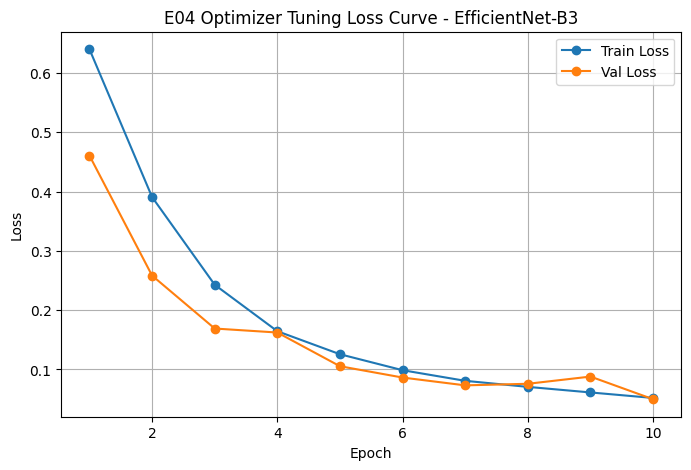

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E04 Optimizer Tuning Loss Curve - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E04_loss_curve.png", bbox_inches="tight")
plt.show()

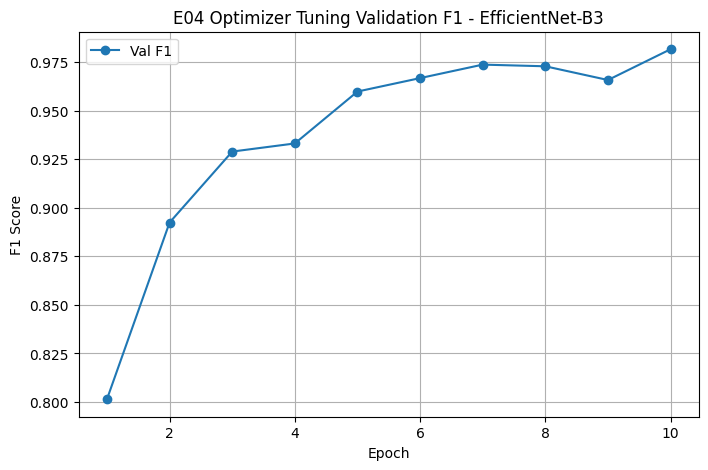

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("E04 Optimizer Tuning Validation F1 - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E04_val_f1.png", bbox_inches="tight")
plt.show()

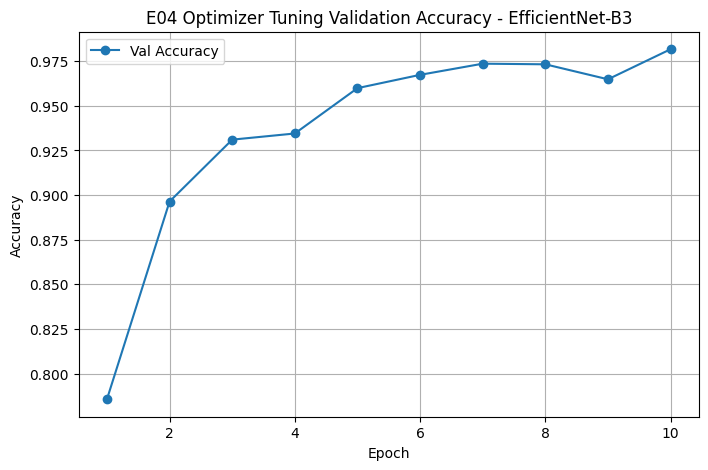

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E04 Optimizer Tuning Validation Accuracy - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E04_val_accuracy.png", bbox_inches="tight")
plt.show()

### 16.2 E05 Optimizer=SGD

In [34]:
config = {
    "run_id": "E05",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "SGD",
    "lr": 3e-4,
    "weight_decay": 1e-4,
    "augmentation": "light",
    "batch_size": 8,
    "scheduler": "none",
    "notes": "optimizer tuning: SGD with best lr=3e-4",
}

In [35]:
history_df, run_result = run_experiment(config)
history_df

Starting run: E05
Epoch 1/10 | Train Loss: 0.6161 | Val Loss: 1.2893 | Val F1: 0.7534
Epoch 2/10 | Train Loss: 0.4676 | Val Loss: 0.6946 | Val F1: 0.8445
Epoch 3/10 | Train Loss: 0.3731 | Val Loss: 1.3878 | Val F1: 0.8680
Epoch 4/10 | Train Loss: 0.2917 | Val Loss: 0.2142 | Val F1: 0.9163
Epoch 5/10 | Train Loss: 0.2298 | Val Loss: 0.1853 | Val F1: 0.9284
Epoch 6/10 | Train Loss: 0.1802 | Val Loss: 0.1724 | Val F1: 0.9314
Epoch 7/10 | Train Loss: 0.1493 | Val Loss: 0.1321 | Val F1: 0.9501
Epoch 8/10 | Train Loss: 0.1224 | Val Loss: 0.1027 | Val F1: 0.9612
Epoch 9/10 | Train Loss: 0.1029 | Val Loss: 0.1034 | Val F1: 0.9628
Epoch 10/10 | Train Loss: 0.0861 | Val Loss: 0.0762 | Val F1: 0.9724
Saved results to C:\Users\Richa\anaconda_projects\results\efficientnet_experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\E05_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.616120,1.289329,0.76105,0.778335,0.7300,0.753393,0.820504
1,2,0.467634,0.694580,0.84270,0.835126,0.8540,0.844458,0.916609
2,3,0.373079,1.387765,0.87215,0.896875,0.8410,0.868039,0.936994
3,4,0.291704,0.214212,0.91645,0.918164,0.9144,0.916278,0.973749
4,5,0.229815,0.185344,0.92935,0.940856,0.9163,0.928416,0.980916
5,6,0.180150,0.172440,0.93410,0.970824,0.8951,0.931426,0.987955
6,7,0.149289,0.132054,0.95115,0.970095,0.9310,0.950145,0.991367
7,8,0.122369,0.102730,0.96090,0.953374,0.9692,0.961222,0.993352
8,9,0.102864,0.103405,0.96195,0.942100,0.9844,0.962785,0.994702
9,10,0.086097,0.076183,0.97215,0.964303,0.9806,0.972383,0.996279


In [36]:
run_result

{'run_id': 'E05',
 'model': 'EfficientNet-B3',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'SGD',
 'learning_rate': 0.0003,
 'weight_decay': 0.0001,
 'augmentation': 'light',
 'scheduler': 'none',
 'val_loss': 0.07618333761719819,
 'val_accuracy': 0.97215,
 'val_precision': 0.9643032746582751,
 'val_recall': 0.9806,
 'val_f1': 0.9723833606029054,
 'val_roc_auc': 0.996278695,
 'best_epoch': 10,
 'train_time_min': 200.74796805381774,
 'checkpoint_saved': 'E05_best.pth',
 'notes': 'optimizer tuning: SGD with best lr=3e-4'}

In [37]:
excel_row_df = pd.DataFrame([{
    "Run ID": run_result["run_id"],
    "Run Type": run_result["run_type"],
    "Model": run_result["model"],
    "Input Size": 224,
    "Loss Function": "CrossEntropyLoss",
    "Epochs": run_result["epochs"],
    "Learning Rate": run_result["learning_rate"],
    "Optimizer": run_result["optimizer"],
    "Weight Decay": run_result["weight_decay"],
    "Augmentation": run_result["augmentation"],
    "Batch Size": run_result["batch_size"],
    "Scheduler": run_result["scheduler"],
    "Val Loss": run_result["val_loss"],
    "Val Accuracy": run_result["val_accuracy"],
    "Val Precision": run_result["val_precision"],
    "Val Recall": run_result["val_recall"],
    "Val F1": run_result["val_f1"],
    "Val ROC-AUC": run_result["val_roc_auc"],
    "Best Epoch": run_result["best_epoch"],
    "Train Time (min)": run_result["train_time_min"],
    "Checkpoint Saved": run_result["checkpoint_saved"],
    "Notes": run_result["notes"],
}])

excel_row_df

,Run ID,Run Type,Model,Input Size,Loss Function,Epochs,Learning Rate,Optimizer,Weight Decay,Augmentation,...,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Best Epoch,Train Time (min),Checkpoint Saved,Notes
0,E05,tuning,EfficientNet-B3,224,CrossEntropyLoss,10,0.0003,SGD,0.0001,light,...,0.076183,0.97215,0.964303,0.9806,0.972383,0.996279,10,200.747968,E05_best.pth,optimizer tuning: SGD with best lr=3e-4


### 16.2.1 Save E05 History and Plots

In [38]:
history_path = results_dir / "E05_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\E05_history.csv


In [39]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


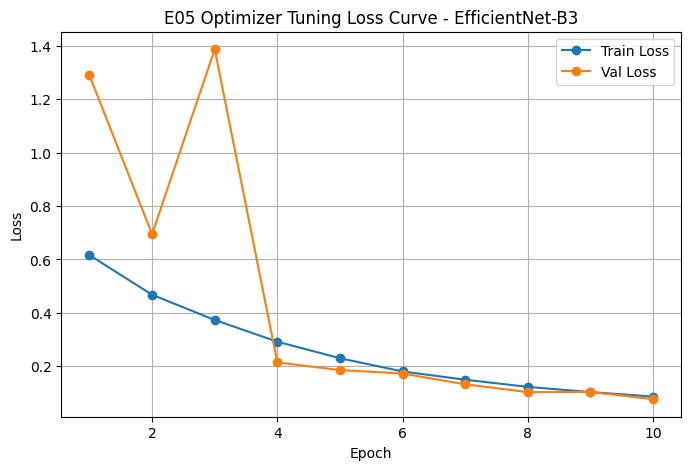

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E05 Optimizer Tuning Loss Curve - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E05_loss_curve.png", bbox_inches="tight")
plt.show()

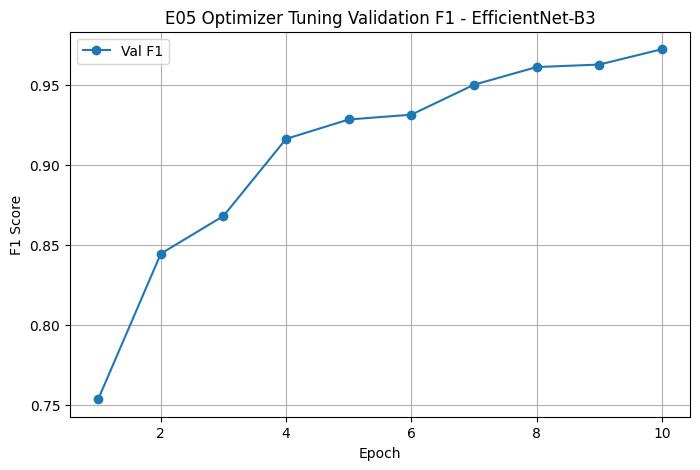

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("E05 Optimizer Tuning Validation F1 - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E05_val_f1.png", bbox_inches="tight")
plt.show()

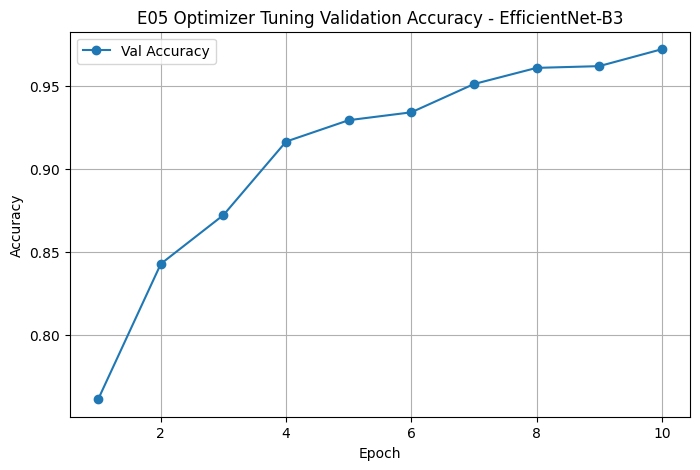

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E05 Optimizer Tuning Validation Accuracy - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E05_val_accuracy.png", bbox_inches="tight")
plt.show()

## 17. Weight Decay Tuning

### 17.1 E06 Weight Decay = 1e-5

In [43]:
config = {
    "run_id": "E06",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 3e-4,
    "weight_decay": 1e-5,
    "augmentation": "light",
    "batch_size": 8,
    "scheduler": "none",
    "notes": "weight decay tuning: wd=1e-5 with best lr=3e-4 and optimizer=AdamW",
}

In [44]:
history_df, run_result = run_experiment(config)
history_df

Starting run: E06
Epoch 1/10 | Train Loss: 0.5497 | Val Loss: 0.3467 | Val F1: 0.8590
Epoch 2/10 | Train Loss: 0.2979 | Val Loss: 0.1938 | Val F1: 0.9203
Epoch 3/10 | Train Loss: 0.1830 | Val Loss: 0.1830 | Val F1: 0.9334
Epoch 4/10 | Train Loss: 0.1323 | Val Loss: 0.1087 | Val F1: 0.9596
Epoch 5/10 | Train Loss: 0.0998 | Val Loss: 0.0823 | Val F1: 0.9690
Epoch 6/10 | Train Loss: 0.0801 | Val Loss: 0.0647 | Val F1: 0.9763
Epoch 7/10 | Train Loss: 0.0680 | Val Loss: 0.0694 | Val F1: 0.9740
Epoch 8/10 | Train Loss: 0.0564 | Val Loss: 0.0604 | Val F1: 0.9787
Epoch 9/10 | Train Loss: 0.0502 | Val Loss: 0.0526 | Val F1: 0.9808
Epoch 10/10 | Train Loss: 0.0445 | Val Loss: 0.0565 | Val F1: 0.9795
Saved results to C:\Users\Richa\anaconda_projects\results\efficientnet_experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\E06_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.549726,0.346676,0.85330,0.827009,0.8935,0.858969,0.929513
1,2,0.297908,0.193759,0.92165,0.936988,0.9041,0.920250,0.978246
2,3,0.182989,0.183026,0.92980,0.887836,0.9839,0.933403,0.988201
3,4,0.132289,0.108715,0.95940,0.954042,0.9653,0.959638,0.992948
4,5,0.099840,0.082327,0.96920,0.974899,0.9632,0.969014,0.996125
5,6,0.080115,0.064716,0.97630,0.976681,0.9759,0.976291,0.997361
6,7,0.067956,0.069392,0.97390,0.970419,0.9776,0.973996,0.996853
7,8,0.056398,0.060382,0.97855,0.971060,0.9865,0.978719,0.997732
8,9,0.050225,0.052605,0.98060,0.969703,0.9922,0.980822,0.998543
9,10,0.044544,0.056501,0.97945,0.978541,0.9804,0.979470,0.998015


In [45]:
run_result

{'run_id': 'E06',
 'model': 'EfficientNet-B3',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.0003,
 'weight_decay': 1e-05,
 'augmentation': 'light',
 'scheduler': 'none',
 'val_loss': 0.05260539394853768,
 'val_accuracy': 0.9806,
 'val_precision': 0.9697028928850665,
 'val_recall': 0.9922,
 'val_f1': 0.9808224594701463,
 'val_roc_auc': 0.9985426950000001,
 'best_epoch': 9,
 'train_time_min': 202.71255568265914,
 'checkpoint_saved': 'E06_best.pth',
 'notes': 'weight decay tuning: wd=1e-5 with best lr=3e-4 and optimizer=AdamW'}

In [46]:
excel_row_df = pd.DataFrame([{
    "Run ID": run_result["run_id"],
    "Run Type": run_result["run_type"],
    "Model": run_result["model"],
    "Input Size": 224,
    "Loss Function": "CrossEntropyLoss",
    "Epochs": run_result["epochs"],
    "Learning Rate": run_result["learning_rate"],
    "Optimizer": run_result["optimizer"],
    "Weight Decay": run_result["weight_decay"],
    "Augmentation": run_result["augmentation"],
    "Batch Size": run_result["batch_size"],
    "Scheduler": run_result["scheduler"],
    "Val Loss": run_result["val_loss"],
    "Val Accuracy": run_result["val_accuracy"],
    "Val Precision": run_result["val_precision"],
    "Val Recall": run_result["val_recall"],
    "Val F1": run_result["val_f1"],
    "Val ROC-AUC": run_result["val_roc_auc"],
    "Best Epoch": run_result["best_epoch"],
    "Train Time (min)": run_result["train_time_min"],
    "Checkpoint Saved": run_result["checkpoint_saved"],
    "Notes": run_result["notes"],
}])

excel_row_df

,Run ID,Run Type,Model,Input Size,Loss Function,Epochs,Learning Rate,Optimizer,Weight Decay,Augmentation,...,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Best Epoch,Train Time (min),Checkpoint Saved,Notes
0,E06,tuning,EfficientNet-B3,224,CrossEntropyLoss,10,0.0003,AdamW,0.00001,light,...,0.052605,0.9806,0.969703,0.9922,0.980822,0.998543,9,202.712556,E06_best.pth,weight decay tuning: wd=1e-5 with best lr=3e-4...


### 17.1.1 Save E06 History and Plots

In [47]:
history_path = results_dir / "E06_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\E06_history.csv


In [48]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


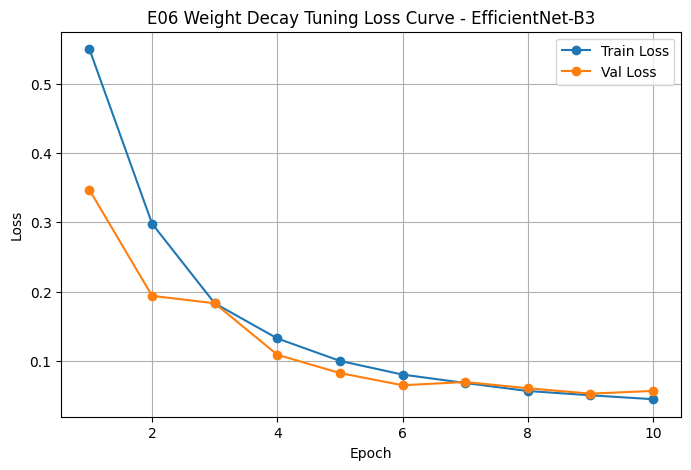

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E06 Weight Decay Tuning Loss Curve - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E06_loss_curve.png", bbox_inches="tight")
plt.show()

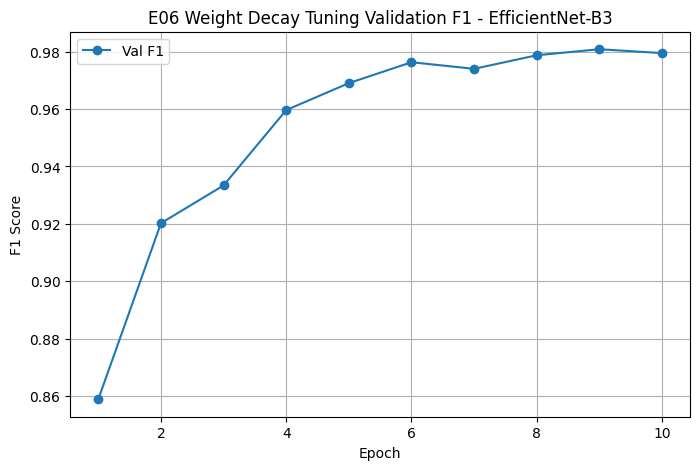

In [50]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("E06 Weight Decay Tuning Validation F1 - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E06_val_f1.png", bbox_inches="tight")
plt.show()

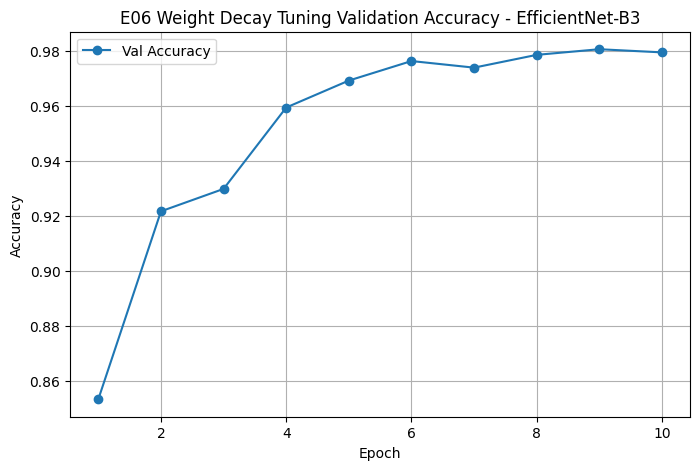

In [51]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E06 Weight Decay Tuning Validation Accuracy - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E06_val_accuracy.png", bbox_inches="tight")
plt.show()

### 17.2 E07 Weight Decay = 1e-3

In [15]:
config = {
    "run_id": "E07",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 3e-4,
    "weight_decay": 1e-3,
    "augmentation": "light",
    "batch_size": 8,
    "scheduler": "none",
    "notes": "weight decay tuning: wd=1e-3 with best lr=3e-4 and optimizer=AdamW",
}

In [16]:
history_df, run_result = run_experiment(config)
history_df

Starting run: E07
Epoch 1/10 | Train Loss: 0.5931 | Val Loss: 0.3997 | Val F1: 0.8175
Epoch 2/10 | Train Loss: 0.3400 | Val Loss: 0.2155 | Val F1: 0.9152
Epoch 3/10 | Train Loss: 0.2030 | Val Loss: 0.1461 | Val F1: 0.9435
Epoch 4/10 | Train Loss: 0.1435 | Val Loss: 0.1282 | Val F1: 0.9520
Epoch 5/10 | Train Loss: 0.1081 | Val Loss: 0.1011 | Val F1: 0.9624
Epoch 6/10 | Train Loss: 0.0860 | Val Loss: 0.0763 | Val F1: 0.9709
Epoch 7/10 | Train Loss: 0.0731 | Val Loss: 0.0640 | Val F1: 0.9758
Epoch 8/10 | Train Loss: 0.0610 | Val Loss: 0.0566 | Val F1: 0.9777
Epoch 9/10 | Train Loss: 0.0538 | Val Loss: 0.0565 | Val F1: 0.9797
Epoch 10/10 | Train Loss: 0.0479 | Val Loss: 0.0420 | Val F1: 0.9840
Saved results to C:\Users\Richa\anaconda_projects\results\efficientnet_experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\E07_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.593078,0.399663,0.82175,0.837300,0.7987,0.817544,0.902790
1,2,0.339964,0.215466,0.91335,0.895891,0.9354,0.915219,0.971789
2,3,0.202954,0.146086,0.94330,0.939695,0.9474,0.943532,0.987107
3,4,0.143474,0.128167,0.95115,0.936273,0.9682,0.951969,0.989711
4,5,0.108132,0.101102,0.96145,0.938266,0.9879,0.962443,0.995431
5,6,0.086048,0.076343,0.97075,0.964480,0.9775,0.970946,0.996218
6,7,0.073075,0.063985,0.97585,0.979736,0.9718,0.975752,0.997542
7,8,0.061033,0.056645,0.97785,0.985966,0.9695,0.977663,0.998226
8,9,0.053784,0.056547,0.97970,0.978075,0.9814,0.979734,0.997863
9,10,0.047887,0.041985,0.98395,0.981399,0.9866,0.983992,0.998910


In [17]:
run_result

{'run_id': 'E07',
 'model': 'EfficientNet-B3',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.0003,
 'weight_decay': 0.001,
 'augmentation': 'light',
 'scheduler': 'none',
 'val_loss': 0.04198506778628289,
 'val_accuracy': 0.98395,
 'val_precision': 0.9813985874863225,
 'val_recall': 0.9866,
 'val_f1': 0.98399242008677,
 'val_roc_auc': 0.99890967,
 'best_epoch': 10,
 'train_time_min': 203.84234215815863,
 'checkpoint_saved': 'E07_best.pth',
 'notes': 'weight decay tuning: wd=1e-3 with best lr=3e-4 and optimizer=AdamW'}

In [18]:
excel_row_df = pd.DataFrame([{
    "Run ID": run_result["run_id"],
    "Run Type": run_result["run_type"],
    "Model": run_result["model"],
    "Input Size": 224,
    "Loss Function": "CrossEntropyLoss",
    "Epochs": run_result["epochs"],
    "Learning Rate": run_result["learning_rate"],
    "Optimizer": run_result["optimizer"],
    "Weight Decay": run_result["weight_decay"],
    "Augmentation": run_result["augmentation"],
    "Batch Size": run_result["batch_size"],
    "Scheduler": run_result["scheduler"],
    "Val Loss": run_result["val_loss"],
    "Val Accuracy": run_result["val_accuracy"],
    "Val Precision": run_result["val_precision"],
    "Val Recall": run_result["val_recall"],
    "Val F1": run_result["val_f1"],
    "Val ROC-AUC": run_result["val_roc_auc"],
    "Best Epoch": run_result["best_epoch"],
    "Train Time (min)": run_result["train_time_min"],
    "Checkpoint Saved": run_result["checkpoint_saved"],
    "Notes": run_result["notes"],
}])

excel_row_df

,Run ID,Run Type,Model,Input Size,Loss Function,Epochs,Learning Rate,Optimizer,Weight Decay,Augmentation,...,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Best Epoch,Train Time (min),Checkpoint Saved,Notes
0,E07,tuning,EfficientNet-B3,224,CrossEntropyLoss,10,0.0003,AdamW,0.001,light,...,0.041985,0.98395,0.981399,0.9866,0.983992,0.99891,10,203.842342,E07_best.pth,weight decay tuning: wd=1e-3 with best lr=3e-4...


### 17.2.1 Save E07 History and Plots

In [19]:
history_path = results_dir / "E07_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\E07_history.csv


In [20]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


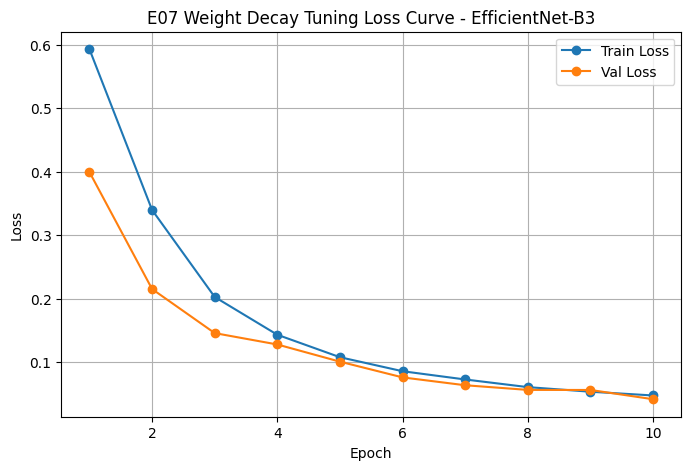

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E07 Weight Decay Tuning Loss Curve - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E07_loss_curve.png", bbox_inches="tight")
plt.show()

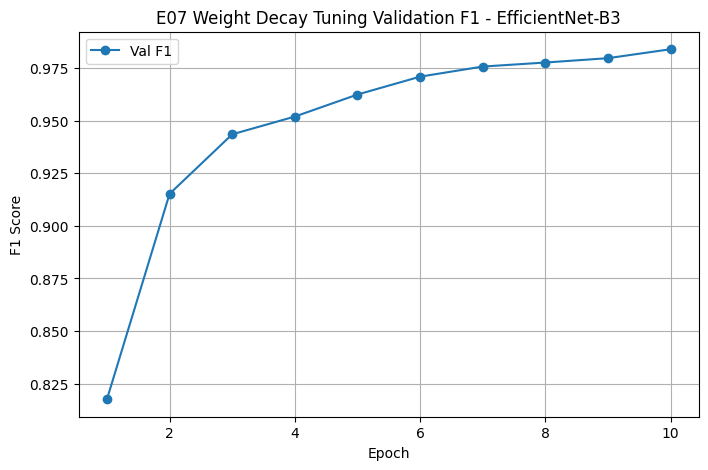

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("E07 Weight Decay Tuning Validation F1 - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E07_val_f1.png", bbox_inches="tight")
plt.show()

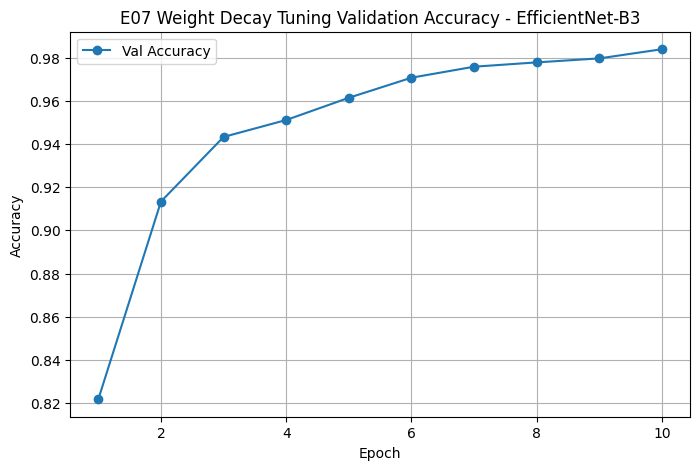

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E07 Weight Decay Tuning Validation Accuracy - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E07_val_accuracy.png", bbox_inches="tight")
plt.show()

## 18. Augmentation Tuning

Since Light Augmentation is already the current best refernce, the augmentation stage should test the alternatives against it. So we will skip light augmentation.

### 18.1 E10 Augmentation = medium

In [24]:
config = {
    "run_id": "E08",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 3e-4,
    "weight_decay": 1e-3,
    "augmentation": "medium",
    "batch_size": 8,
    "scheduler": "none",
    "notes": "augmentation tuning: medium with best lr=3e-4, optimizer=AdamW, wd=1e-3",
}

In [25]:
history_df, run_result = run_experiment(config)
history_df

Starting run: E08
Epoch 1/10 | Train Loss: 0.6970 | Val Loss: 0.6928 | Val F1: 0.6034
Epoch 2/10 | Train Loss: 0.6949 | Val Loss: 0.6941 | Val F1: 0.1854
Epoch 3/10 | Train Loss: 0.6946 | Val Loss: 0.6950 | Val F1: 0.6478
Epoch 4/10 | Train Loss: 0.6940 | Val Loss: 0.6993 | Val F1: 0.1296
Epoch 5/10 | Train Loss: 0.6938 | Val Loss: 0.6940 | Val F1: 0.6667
Epoch 6/10 | Train Loss: 0.6937 | Val Loss: 0.6932 | Val F1: 0.5761
Epoch 7/10 | Train Loss: 0.6938 | Val Loss: 0.6931 | Val F1: 0.1581
Epoch 8/10 | Train Loss: 0.6935 | Val Loss: 0.6929 | Val F1: 0.6664
Early stopping triggered.
Saved results to C:\Users\Richa\anaconda_projects\results\efficientnet_experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\E08_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.696964,0.692818,0.5144,0.509938,0.7389,0.603430,0.532969
1,2,0.694902,0.694107,0.5167,0.589496,0.1100,0.185404,0.506697
2,3,0.694569,0.695030,0.5004,0.500218,0.9190,0.647822,0.484312
3,4,0.694023,0.699348,0.4997,0.497995,0.0745,0.129610,0.477982
4,5,0.693762,0.693956,0.5000,0.500000,1.0000,0.666667,0.511391
5,6,0.693698,0.693186,0.4920,0.494273,0.6904,0.576101,0.492500
6,7,0.693811,0.693098,0.5006,0.503219,0.0938,0.158125,0.512727
7,8,0.693498,0.692862,0.4999,0.499950,0.9992,0.666444,0.491479


In [26]:
run_result

{'run_id': 'E08',
 'model': 'EfficientNet-B3',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.0003,
 'weight_decay': 0.001,
 'augmentation': 'medium',
 'scheduler': 'none',
 'val_loss': 0.6939557969808579,
 'val_accuracy': 0.5,
 'val_precision': 0.5,
 'val_recall': 1.0,
 'val_f1': 0.6666666666666666,
 'val_roc_auc': 0.5113907400000001,
 'best_epoch': 5,
 'train_time_min': 166.20322298208873,
 'checkpoint_saved': 'E08_best.pth',
 'notes': 'augmentation tuning: medium with best lr=3e-4, optimizer=AdamW, wd=1e-3'}

In [27]:
excel_row_df = pd.DataFrame([{
    "Run ID": run_result["run_id"],
    "Run Type": run_result["run_type"],
    "Model": run_result["model"],
    "Input Size": 224,
    "Loss Function": "CrossEntropyLoss",
    "Epochs": run_result["epochs"],
    "Learning Rate": run_result["learning_rate"],
    "Optimizer": run_result["optimizer"],
    "Weight Decay": run_result["weight_decay"],
    "Augmentation": run_result["augmentation"],
    "Batch Size": run_result["batch_size"],
    "Scheduler": run_result["scheduler"],
    "Val Loss": run_result["val_loss"],
    "Val Accuracy": run_result["val_accuracy"],
    "Val Precision": run_result["val_precision"],
    "Val Recall": run_result["val_recall"],
    "Val F1": run_result["val_f1"],
    "Val ROC-AUC": run_result["val_roc_auc"],
    "Best Epoch": run_result["best_epoch"],
    "Train Time (min)": run_result["train_time_min"],
    "Checkpoint Saved": run_result["checkpoint_saved"],
    "Notes": run_result["notes"],
}])

excel_row_df

,Run ID,Run Type,Model,Input Size,Loss Function,Epochs,Learning Rate,Optimizer,Weight Decay,Augmentation,...,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Best Epoch,Train Time (min),Checkpoint Saved,Notes
0,E08,tuning,EfficientNet-B3,224,CrossEntropyLoss,10,0.0003,AdamW,0.001,medium,...,0.693956,0.5,0.5,1.0,0.666667,0.511391,5,166.203223,E08_best.pth,"augmentation tuning: medium with best lr=3e-4,..."


### 18.1.1 Save E08 History and Plots

In [28]:
history_path = results_dir / "E08_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\E08_history.csv


In [29]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


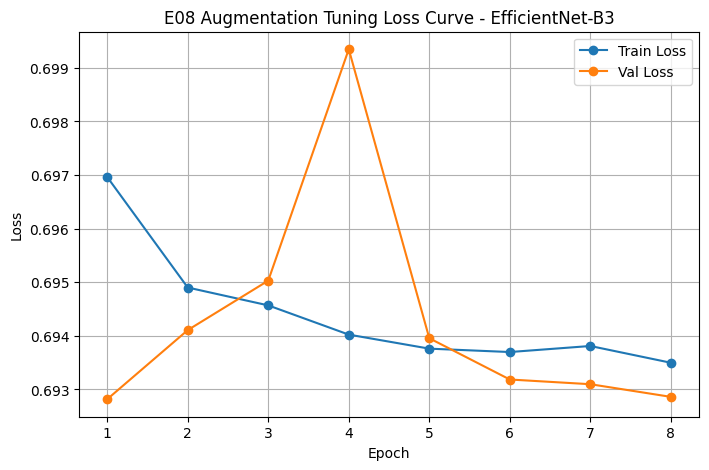

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E08 Augmentation Tuning Loss Curve - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E08_loss_curve.png", bbox_inches="tight")
plt.show()

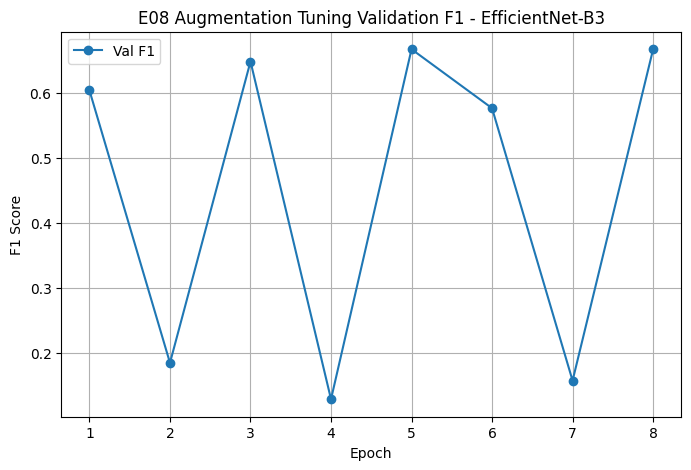

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("E08 Augmentation Tuning Validation F1 - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E08_val_f1.png", bbox_inches="tight")
plt.show()

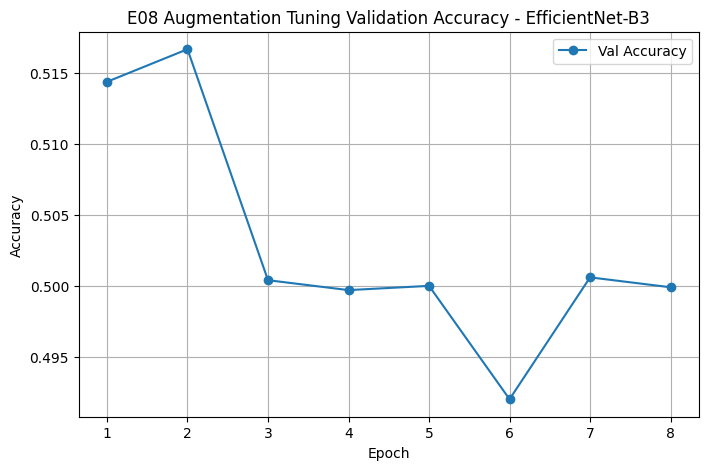

In [32]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E08 Augmentation Tuning Validation Accuracy - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E08_val_accuracy.png", bbox_inches="tight")
plt.show()

### 18.2 E09 Augmentation = strong

In [15]:
config = {
    "run_id": "E09",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 3e-4,
    "weight_decay": 1e-3,
    "augmentation": "strong",
    "batch_size": 8,
    "scheduler": "none",
    "notes": "augmentation tuning: strong with best lr=3e-4, optimizer=AdamW, wd=1e-3",
}

In [16]:
history_df, run_result = run_experiment(config)
history_df

Starting run: E09
Epoch 1/10 | Train Loss: 0.6976 | Val Loss: 0.6962 | Val F1: 0.2714
Epoch 2/10 | Train Loss: 0.6951 | Val Loss: 0.6942 | Val F1: 0.4561
Epoch 3/10 | Train Loss: 0.6946 | Val Loss: 0.6975 | Val F1: 0.1971
Epoch 4/10 | Train Loss: 0.6943 | Val Loss: 0.6950 | Val F1: 0.1858
Epoch 5/10 | Train Loss: 0.6941 | Val Loss: 0.6930 | Val F1: 0.1336
Early stopping triggered.
Saved results to C:\Users\Richa\anaconda_projects\results\efficientnet_experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\E09_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.697601,0.696234,0.49765,0.493798,0.1871,0.271376,0.509559
1,2,0.695076,0.694185,0.49310,0.492012,0.4250,0.456058,0.493464
2,3,0.694631,0.697524,0.49935,0.497369,0.1229,0.197097,0.532258
3,4,0.694318,0.695005,0.51185,0.559518,0.1114,0.185806,0.532979
4,5,0.694083,0.692983,0.50515,0.536191,0.0763,0.133590,0.486444


In [17]:
run_result

{'run_id': 'E09',
 'model': 'EfficientNet-B3',
 'run_type': 'tuning',
 'batch_size': 8,
 'epochs': 10,
 'optimizer': 'AdamW',
 'learning_rate': 0.0003,
 'weight_decay': 0.001,
 'augmentation': 'strong',
 'scheduler': 'none',
 'val_loss': 0.6941845724821091,
 'val_accuracy': 0.4931,
 'val_precision': 0.49201203982403335,
 'val_recall': 0.425,
 'val_f1': 0.45605751690095503,
 'val_roc_auc': 0.49346445499999997,
 'best_epoch': 2,
 'train_time_min': 101.88590703407924,
 'checkpoint_saved': 'E09_best.pth',
 'notes': 'augmentation tuning: strong with best lr=3e-4, optimizer=AdamW, wd=1e-3'}

In [18]:
excel_row_df = pd.DataFrame([{
    "Run ID": run_result["run_id"],
    "Run Type": run_result["run_type"],
    "Model": run_result["model"],
    "Input Size": 224,
    "Loss Function": "CrossEntropyLoss",
    "Epochs": run_result["epochs"],
    "Learning Rate": run_result["learning_rate"],
    "Optimizer": run_result["optimizer"],
    "Weight Decay": run_result["weight_decay"],
    "Augmentation": run_result["augmentation"],
    "Batch Size": run_result["batch_size"],
    "Scheduler": run_result["scheduler"],
    "Val Loss": run_result["val_loss"],
    "Val Accuracy": run_result["val_accuracy"],
    "Val Precision": run_result["val_precision"],
    "Val Recall": run_result["val_recall"],
    "Val F1": run_result["val_f1"],
    "Val ROC-AUC": run_result["val_roc_auc"],
    "Best Epoch": run_result["best_epoch"],
    "Train Time (min)": run_result["train_time_min"],
    "Checkpoint Saved": run_result["checkpoint_saved"],
    "Notes": run_result["notes"],
}])

excel_row_df

,Run ID,Run Type,Model,Input Size,Loss Function,Epochs,Learning Rate,Optimizer,Weight Decay,Augmentation,...,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Best Epoch,Train Time (min),Checkpoint Saved,Notes
0,E09,tuning,EfficientNet-B3,224,CrossEntropyLoss,10,0.0003,AdamW,0.001,strong,...,0.694185,0.4931,0.492012,0.425,0.456058,0.493464,2,101.885907,E09_best.pth,"augmentation tuning: strong with best lr=3e-4,..."


### 18.2.1 Save E09 History and Plots

In [19]:
history_path = results_dir / "E09_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\E09_history.csv


In [20]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


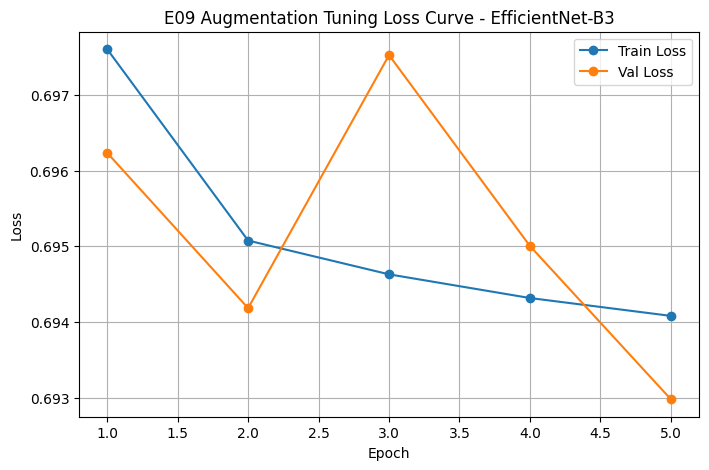

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E09 Augmentation Tuning Loss Curve - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E09_loss_curve.png", bbox_inches="tight")
plt.show()

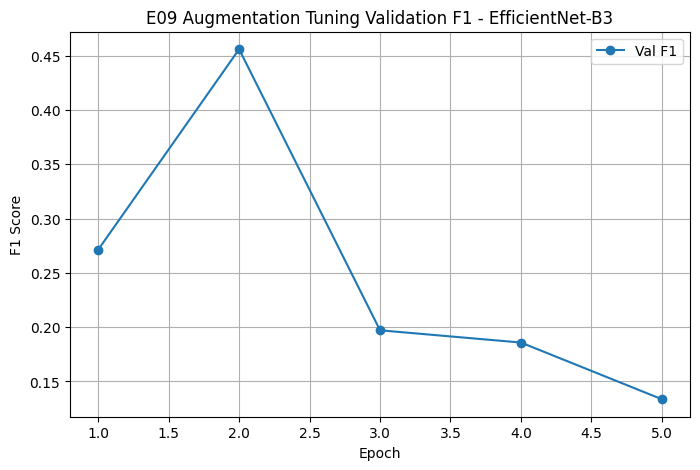

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("E09 Augmentation Tuning Validation F1 - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E09_val_f1.png", bbox_inches="tight")
plt.show()

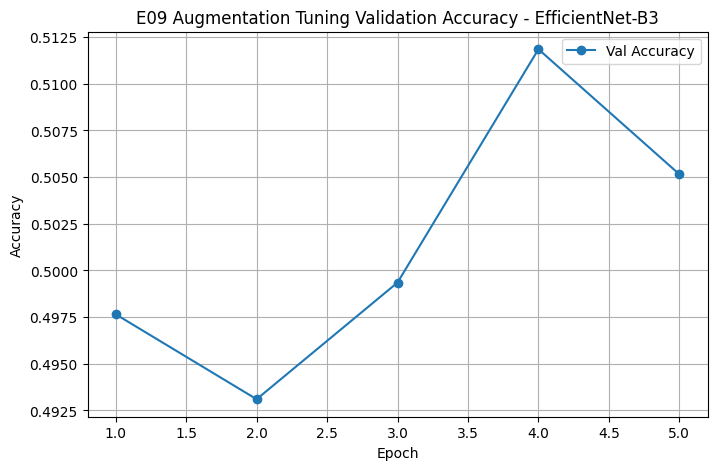

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E09 Augmentation Tuning Validation Accuracy - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E09_val_accuracy.png", bbox_inches="tight")
plt.show()

## 19. Batch Size Tuning

### 19.1 E10 Batch Size = 16

In [24]:
config = {
    "run_id": "E10",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 3e-4,
    "weight_decay": 1e-3,
    "augmentation": "light",
    "batch_size": 16,
    "scheduler": "none",
    "notes": "batch size tuning: batch_size=16 with best lr=3e-4, optimizer=AdamW, wd=1e-3, augmentation=light",
}

In [25]:
history_df, run_result = run_experiment(config)
history_df

Starting run: E10
Epoch 1/10 | Train Loss: 0.5005 | Val Loss: 0.3263 | Val F1: 0.8561
Epoch 2/10 | Train Loss: 0.2761 | Val Loss: 0.2010 | Val F1: 0.9202
Epoch 3/10 | Train Loss: 0.1744 | Val Loss: 0.1336 | Val F1: 0.9492
Epoch 4/10 | Train Loss: 0.1264 | Val Loss: 0.0976 | Val F1: 0.9641
Epoch 5/10 | Train Loss: 0.0955 | Val Loss: 0.0972 | Val F1: 0.9642
Epoch 6/10 | Train Loss: 0.0775 | Val Loss: 0.0703 | Val F1: 0.9745
Epoch 7/10 | Train Loss: 0.0636 | Val Loss: 0.0682 | Val F1: 0.9754
Epoch 8/10 | Train Loss: 0.0543 | Val Loss: 0.0582 | Val F1: 0.9800
Epoch 9/10 | Train Loss: 0.0492 | Val Loss: 0.0519 | Val F1: 0.9812
Epoch 10/10 | Train Loss: 0.0413 | Val Loss: 0.0620 | Val F1: 0.9794
Saved results to C:\Users\Richa\anaconda_projects\results\efficientnet_experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\E10_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.500532,0.326330,0.86080,0.886130,0.8280,0.856079,0.938000
1,2,0.276088,0.200981,0.91970,0.914069,0.9265,0.920242,0.974608
2,3,0.174377,0.133622,0.94935,0.951291,0.9472,0.949241,0.988932
3,4,0.126435,0.097617,0.96440,0.972335,0.9560,0.964098,0.994266
4,5,0.095530,0.097244,0.96370,0.951773,0.9769,0.964173,0.994191
5,6,0.077546,0.070257,0.97445,0.973361,0.9756,0.974479,0.996732
6,7,0.063646,0.068247,0.97525,0.970964,0.9798,0.975362,0.996873
7,8,0.054293,0.058188,0.97995,0.976661,0.9834,0.980019,0.997663
8,9,0.049213,0.051898,0.98110,0.975395,0.9871,0.981213,0.998309
9,10,0.041290,0.061971,0.97945,0.982005,0.9768,0.979395,0.997765


In [26]:
excel_row_df = pd.DataFrame([{
    "Run ID": run_result["run_id"],
    "Run Type": run_result["run_type"],
    "Model": run_result["model"],
    "Input Size": 224,
    "Loss Function": "CrossEntropyLoss",
    "Epochs": run_result["epochs"],
    "Learning Rate": run_result["learning_rate"],
    "Optimizer": run_result["optimizer"],
    "Weight Decay": run_result["weight_decay"],
    "Augmentation": run_result["augmentation"],
    "Batch Size": run_result["batch_size"],
    "Scheduler": run_result["scheduler"],
    "Val Loss": run_result["val_loss"],
    "Val Accuracy": run_result["val_accuracy"],
    "Val Precision": run_result["val_precision"],
    "Val Recall": run_result["val_recall"],
    "Val F1": run_result["val_f1"],
    "Val ROC-AUC": run_result["val_roc_auc"],
    "Best Epoch": run_result["best_epoch"],
    "Train Time (min)": run_result["train_time_min"],
    "Checkpoint Saved": run_result["checkpoint_saved"],
    "Notes": run_result["notes"],
}])

excel_row_df

,Run ID,Run Type,Model,Input Size,Loss Function,Epochs,Learning Rate,Optimizer,Weight Decay,Augmentation,...,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Best Epoch,Train Time (min),Checkpoint Saved,Notes
0,E10,tuning,EfficientNet-B3,224,CrossEntropyLoss,10,0.0003,AdamW,0.001,light,...,0.051898,0.9811,0.975395,0.9871,0.981213,0.998309,9,157.466765,E10_best.pth,batch size tuning: batch_size=16 with best lr=...


### 19.1.1 Save E10 History and Plots

In [27]:
history_path = results_dir / "E10_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\E10_history.csv


In [28]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


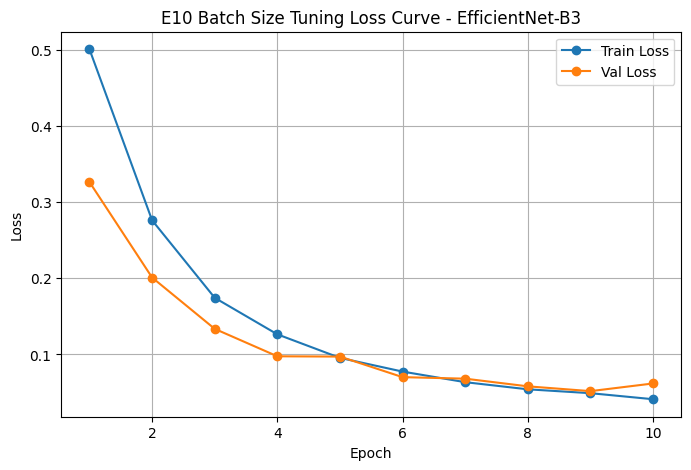

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E10 Batch Size Tuning Loss Curve - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E10_loss_curve.png", bbox_inches="tight")
plt.show()

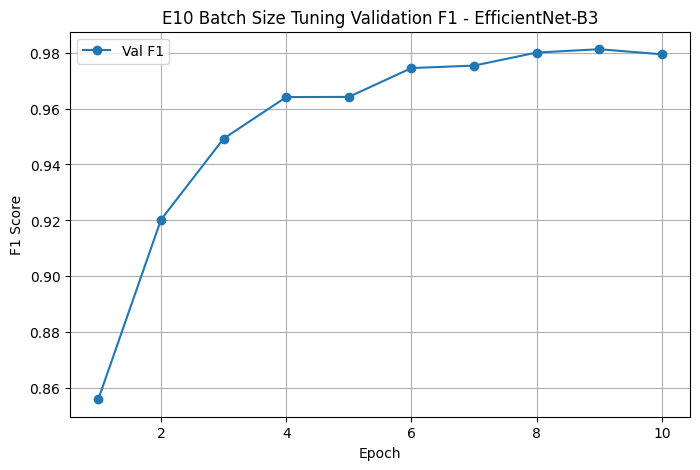

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("E10 Batch Size Tuning Validation F1 - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E10_val_f1.png", bbox_inches="tight")
plt.show()

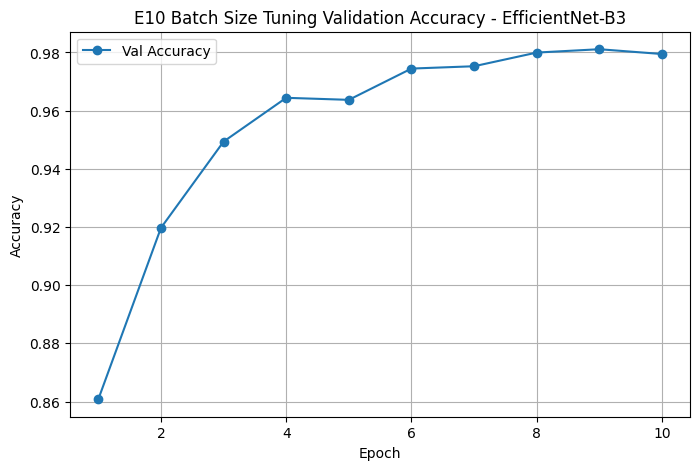

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E10 Batch Size Tuning Validation Accuracy - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E10_val_accuracy.png", bbox_inches="tight")
plt.show()

## 20. Scheduler Tuning

### 20.1 E11 Scheduler = ReduceLROnPlateau

In [15]:
config = {
    "run_id": "E11",
    "run_type": "tuning",
    "epochs": 10,
    "patience": 3,
    "optimizer": "AdamW",
    "lr": 3e-4,
    "weight_decay": 1e-3,
    "augmentation": "light",
    "batch_size": 8,
    "scheduler": "ReduceLROnPlateau",
    "notes": "scheduler tuning: ReduceLROnPlateau with best lr=3e-4, optimizer=AdamW, wd=1e-3, augmentation=light, batch_size=8",
}

In [16]:
history_df, run_result = run_experiment(config)
history_df

Starting run: E11
Epoch 1/10 | Train Loss: 0.5841 | Val Loss: 0.4217 | Val F1: 0.8109
Epoch 2/10 | Train Loss: 0.3422 | Val Loss: 0.2289 | Val F1: 0.9060
Epoch 3/10 | Train Loss: 0.2061 | Val Loss: 0.1664 | Val F1: 0.9369
Epoch 4/10 | Train Loss: 0.1444 | Val Loss: 0.1203 | Val F1: 0.9522
Epoch 5/10 | Train Loss: 0.1136 | Val Loss: 0.0873 | Val F1: 0.9661
Epoch 6/10 | Train Loss: 0.0892 | Val Loss: 0.0734 | Val F1: 0.9722
Epoch 7/10 | Train Loss: 0.0744 | Val Loss: 0.0851 | Val F1: 0.9700
Epoch 8/10 | Train Loss: 0.0635 | Val Loss: 0.0653 | Val F1: 0.9747
Epoch 9/10 | Train Loss: 0.0558 | Val Loss: 0.0551 | Val F1: 0.9801
Epoch 10/10 | Train Loss: 0.0480 | Val Loss: 0.0622 | Val F1: 0.9754
Saved results to C:\Users\Richa\anaconda_projects\results\efficientnet_experiment_log.csv
Saved best checkpoint to C:\Users\Richa\anaconda_projects\checkpoints\E11_best.pth


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc
0,1,0.584056,0.421718,0.81455,0.827077,0.7954,0.810929,0.896551
1,2,0.342152,0.228851,0.90580,0.903781,0.9083,0.906035,0.967677
2,3,0.206106,0.166401,0.93790,0.952096,0.9222,0.936909,0.985759
3,4,0.144435,0.120293,0.95250,0.957625,0.9469,0.952233,0.991072
4,5,0.113560,0.087303,0.96620,0.969960,0.9622,0.966064,0.995500
5,6,0.089205,0.073384,0.97230,0.974864,0.9696,0.972225,0.996656
6,7,0.074411,0.085124,0.96940,0.952042,0.9886,0.969976,0.996778
7,8,0.063471,0.065303,0.97490,0.981058,0.9685,0.974738,0.997466
8,9,0.055836,0.055099,0.98010,0.978092,0.9822,0.980142,0.998048
9,10,0.048033,0.062234,0.97570,0.987497,0.9636,0.975402,0.998038


In [17]:
excel_row_df = pd.DataFrame([{
    "Run ID": run_result["run_id"],
    "Run Type": run_result["run_type"],
    "Model": run_result["model"],
    "Input Size": 224,
    "Loss Function": "CrossEntropyLoss",
    "Epochs": run_result["epochs"],
    "Learning Rate": run_result["learning_rate"],
    "Optimizer": run_result["optimizer"],
    "Weight Decay": run_result["weight_decay"],
    "Augmentation": run_result["augmentation"],
    "Batch Size": run_result["batch_size"],
    "Scheduler": run_result["scheduler"],
    "Val Loss": run_result["val_loss"],
    "Val Accuracy": run_result["val_accuracy"],
    "Val Precision": run_result["val_precision"],
    "Val Recall": run_result["val_recall"],
    "Val F1": run_result["val_f1"],
    "Val ROC-AUC": run_result["val_roc_auc"],
    "Best Epoch": run_result["best_epoch"],
    "Train Time (min)": run_result["train_time_min"],
    "Checkpoint Saved": run_result["checkpoint_saved"],
    "Notes": run_result["notes"],
}])

excel_row_df

,Run ID,Run Type,Model,Input Size,Loss Function,Epochs,Learning Rate,Optimizer,Weight Decay,Augmentation,...,Val Loss,Val Accuracy,Val Precision,Val Recall,Val F1,Val ROC-AUC,Best Epoch,Train Time (min),Checkpoint Saved,Notes
0,E11,tuning,EfficientNet-B3,224,CrossEntropyLoss,10,0.0003,AdamW,0.001,light,...,0.055099,0.9801,0.978092,0.9822,0.980142,0.998048,9,201.923709,E11_best.pth,scheduler tuning: ReduceLROnPlateau with best ...


### 20.1.1 Save E11 History and Plots

In [18]:
history_path = results_dir / "E11_history.csv"
history_df.to_csv(history_path, index=False)
print(f"Saved history to {history_path}")

Saved history to C:\Users\Richa\anaconda_projects\results\E11_history.csv


In [19]:
plots_dir = results_dir / "plots"
plots_dir.mkdir(exist_ok=True)
print(f"Plots will be saved to {plots_dir}")

Plots will be saved to C:\Users\Richa\anaconda_projects\results\plots


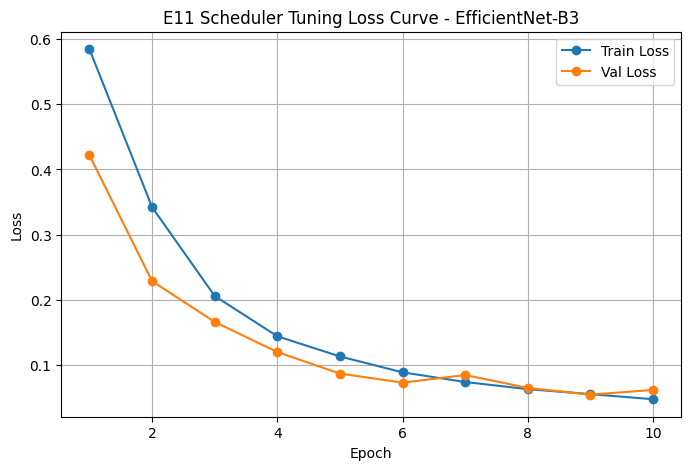

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train Loss")
plt.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("E11 Scheduler Tuning Loss Curve - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E11_loss_curve.png", bbox_inches="tight")
plt.show()

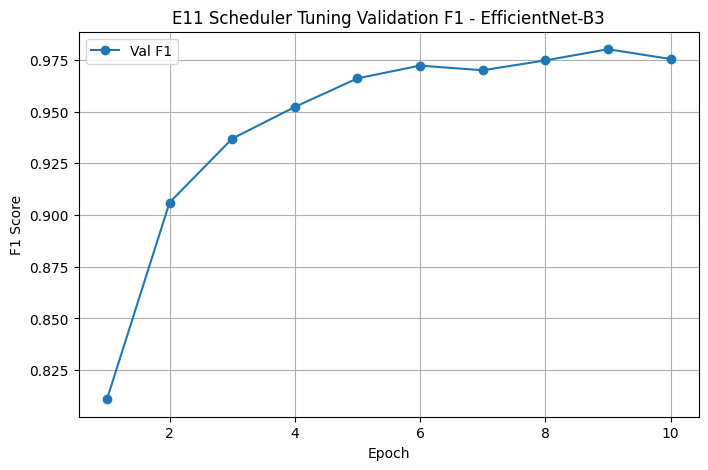

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_f1"], marker="o", label="Val F1")
plt.xlabel("Epoch")
plt.ylabel("F1 Score")
plt.title("E11 Scheduler Tuning Validation F1 - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E11_val_f1.png", bbox_inches="tight")
plt.show()

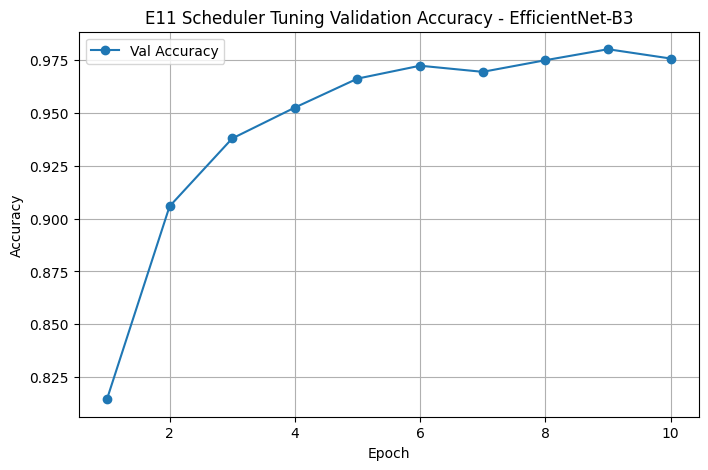

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("E11 Scheduler Tuning Validation Accuracy - EfficientNet-B3")
plt.legend()
plt.grid(True)
plt.savefig(plots_dir / "E11_val_accuracy.png", bbox_inches="tight")
plt.show()

## 21. EfficientNet-B3 Tuning Summary

This section summarizes the main EfficientNet-B3 tuning runs and identifies the best-performing configuration based on validation performance.

### 21.1 EfficientNet-B3 Tuning Comparison Table

In [23]:
efficientnet_summary_df = pd.DataFrame([
    {
        "Run ID": "E01",
        "Stage": "Baseline",
        "Setting": "Adam, lr=1e-3, wd=1e-4, light, bs=8, no scheduler",
        "Val Loss": 0.128220,
        "Val Accuracy": 0.94985,
        "Val F1": 0.949480,
        "Val ROC-AUC": 0.990644,
        "Best Epoch": 10,
    },
    {
        "Run ID": "E02",
        "Stage": "Learning Rate",
        "Setting": "lr=1e-4",
        "Val Loss": 0.074576,
        "Val Accuracy": 0.97185,
        "Val F1": 0.972199,
        "Val ROC-AUC": 0.996586,
        "Best Epoch": 9,
    },
    {
        "Run ID": "E03",
        "Stage": "Learning Rate",
        "Setting": "lr=3e-4",
        "Val Loss": 0.055123,
        "Val Accuracy": 0.97880,
        "Val F1": 0.979049,
        "Val ROC-AUC": 0.998490,
        "Best Epoch": 9,
    },
    {
        "Run ID": "E04",
        "Stage": "Optimizer",
        "Setting": "AdamW",
        "Val Loss": 0.049688,
        "Val Accuracy": 0.98170,
        "Val F1": 0.981744,
        "Val ROC-AUC": 0.998385,
        "Best Epoch": 10,
    },
    {
        "Run ID": "E05",
        "Stage": "Optimizer",
        "Setting": "SGD",
        "Val Loss": 0.076183,
        "Val Accuracy": 0.97215,
        "Val F1": 0.972384,
        "Val ROC-AUC": 0.996279,
        "Best Epoch": 10,
    },
    {
        "Run ID": "E06",
        "Stage": "Weight Decay",
        "Setting": "wd=1e-5",
        "Val Loss": 0.052605,
        "Val Accuracy": 0.98060,
        "Val F1": 0.980822,
        "Val ROC-AUC": 0.998543,
        "Best Epoch": 9,
    },
    {
        "Run ID": "E07",
        "Stage": "Weight Decay",
        "Setting": "wd=1e-3",
        "Val Loss": 0.041985,
        "Val Accuracy": 0.98395,
        "Val F1": 0.983992,
        "Val ROC-AUC": 0.998910,
        "Best Epoch": 10,
    },
    {
        "Run ID": "E08",
        "Stage": "Augmentation",
        "Setting": "medium",
        "Val Loss": 0.693558,
        "Val Accuracy": 0.50000,
        "Val F1": 0.666667,
        "Val ROC-AUC": 0.511391,
        "Best Epoch": 5,
    },
    {
        "Run ID": "E09",
        "Stage": "Augmentation",
        "Setting": "strong",
        "Val Loss": 0.694185,
        "Val Accuracy": 0.49310,
        "Val F1": 0.456058,
        "Val ROC-AUC": 0.493464,
        "Best Epoch": 2,
    },
    {
        "Run ID": "E10",
        "Stage": "Batch Size",
        "Setting": "batch_size=16",
        "Val Loss": 0.051898,
        "Val Accuracy": 0.98110,
        "Val F1": 0.981213,
        "Val ROC-AUC": 0.998309,
        "Best Epoch": 9,
    },
    {
        "Run ID": "E11",
        "Stage": "Scheduler",
        "Setting": "ReduceLROnPlateau",
        "Val Loss": 0.055099,
        "Val Accuracy": 0.98010,
        "Val F1": 0.980142,
        "Val ROC-AUC": 0.998048,
        "Best Epoch": 9,
    },
])

efficientnet_summary_df

,Run ID,Stage,Setting,Val Loss,Val Accuracy,Val F1,Val ROC-AUC,Best Epoch
0,E01,Baseline,"Adam, lr=1e-3, wd=1e-4, light, bs=8, no scheduler",0.128220,0.94985,0.949480,0.990644,10
1,E02,Learning Rate,lr=1e-4,0.074576,0.97185,0.972199,0.996586,9
2,E03,Learning Rate,lr=3e-4,0.055123,0.97880,0.979049,0.998490,9
3,E04,Optimizer,AdamW,0.049688,0.98170,0.981744,0.998385,10
4,E05,Optimizer,SGD,0.076183,0.97215,0.972384,0.996279,10
5,E06,Weight Decay,wd=1e-5,0.052605,0.98060,0.980822,0.998543,9
6,E07,Weight Decay,wd=1e-3,0.041985,0.98395,0.983992,0.998910,10
7,E08,Augmentation,medium,0.693558,0.50000,0.666667,0.511391,5
8,E09,Augmentation,strong,0.694185,0.49310,0.456058,0.493464,2
9,E10,Batch Size,batch_size=16,0.051898,0.98110,0.981213,0.998309,9


### 21.2 Best-Per-Stage Validation F1

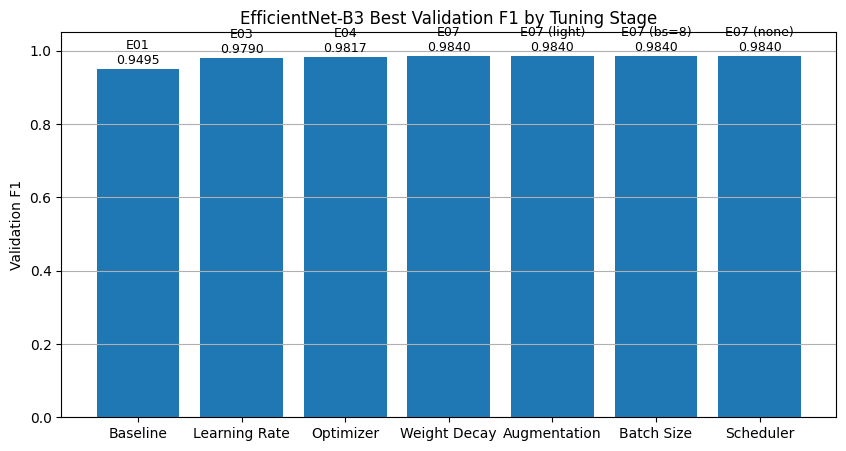

In [24]:
stage_best_df = pd.DataFrame([
    {"Stage": "Baseline", "Run ID": "E01", "Val F1": 0.949480},
    {"Stage": "Learning Rate", "Run ID": "E03", "Val F1": 0.979049},
    {"Stage": "Optimizer", "Run ID": "E04", "Val F1": 0.981744},
    {"Stage": "Weight Decay", "Run ID": "E07", "Val F1": 0.983992},
    {"Stage": "Augmentation", "Run ID": "E07 (light)", "Val F1": 0.983992},
    {"Stage": "Batch Size", "Run ID": "E07 (bs=8)", "Val F1": 0.983992},
    {"Stage": "Scheduler", "Run ID": "E07 (none)", "Val F1": 0.983992},
])

plt.figure(figsize=(10, 5))
bars = plt.bar(stage_best_df["Stage"], stage_best_df["Val F1"])
plt.ylabel("Validation F1")
plt.title("EfficientNet-B3 Best Validation F1 by Tuning Stage")
plt.ylim(0.0, 1.05)
plt.grid(True, axis="y")

for bar, value, run_id in zip(bars, stage_best_df["Val F1"], stage_best_df["Run ID"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{run_id}\n{value:.4f}",
        ha="center",
        fontsize=9
    )

plt.savefig(plots_dir / "efficientnet_best_per_stage_val_f1.png", bbox_inches="tight")
plt.show()

### 21.3 Per-Stage Candidate Comparison Charts

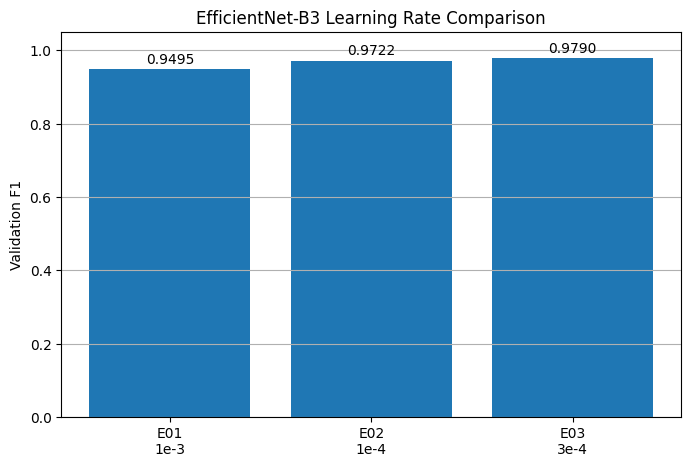

In [25]:
lr_labels = ["E01\n1e-3", "E02\n1e-4", "E03\n3e-4"]
lr_f1 = [0.949480, 0.972199, 0.979049]

plt.figure(figsize=(8, 5))
bars = plt.bar(lr_labels, lr_f1)
plt.ylabel("Validation F1")
plt.title("EfficientNet-B3 Learning Rate Comparison")
plt.ylim(0.0, 1.05)
plt.grid(True, axis="y")

for bar, value in zip(bars, lr_f1):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.015, f"{value:.4f}", ha="center")

plt.savefig(plots_dir / "efficientnet_lr_comparison.png", bbox_inches="tight")
plt.show()

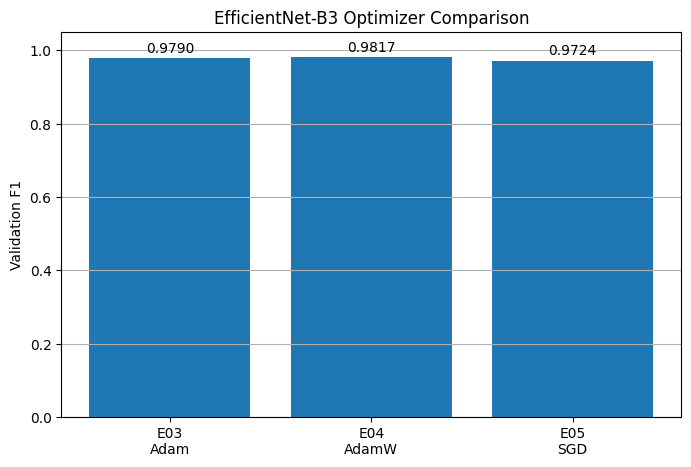

In [26]:
opt_labels = ["E03\nAdam", "E04\nAdamW", "E05\nSGD"]
opt_f1 = [0.979049, 0.981744, 0.972384]

plt.figure(figsize=(8, 5))
bars = plt.bar(opt_labels, opt_f1)
plt.ylabel("Validation F1")
plt.title("EfficientNet-B3 Optimizer Comparison")
plt.ylim(0.0, 1.05)
plt.grid(True, axis="y")

for bar, value in zip(bars, opt_f1):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.015, f"{value:.4f}", ha="center")

plt.savefig(plots_dir / "efficientnet_optimizer_comparison.png", bbox_inches="tight")
plt.show()

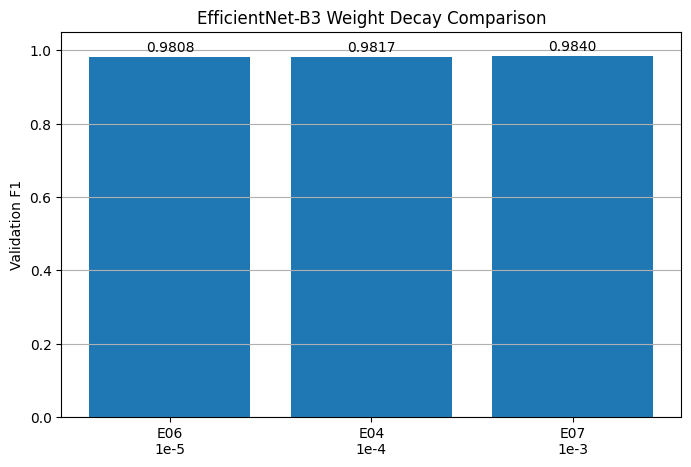

In [27]:
wd_labels = ["E06\n1e-5", "E04\n1e-4", "E07\n1e-3"]
wd_f1 = [0.980822, 0.981744, 0.983992]

plt.figure(figsize=(8, 5))
bars = plt.bar(wd_labels, wd_f1)
plt.ylabel("Validation F1")
plt.title("EfficientNet-B3 Weight Decay Comparison")
plt.ylim(0.0, 1.05)
plt.grid(True, axis="y")

for bar, value in zip(bars, wd_f1):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.015, f"{value:.4f}", ha="center")

plt.savefig(plots_dir / "efficientnet_weight_decay_comparison.png", bbox_inches="tight")
plt.show()

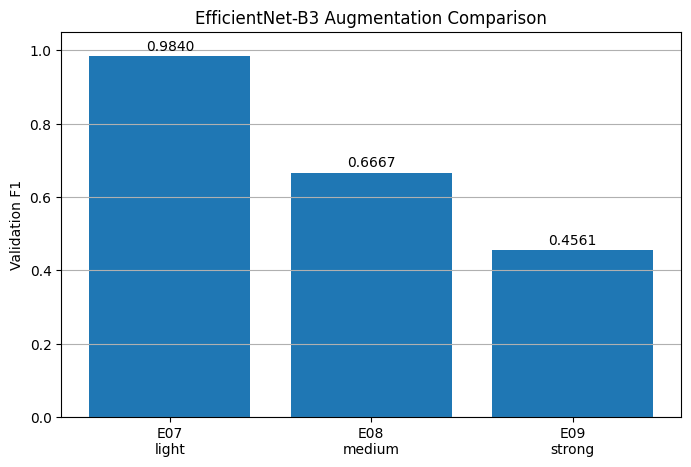

In [28]:
aug_labels = ["E07\nlight", "E08\nmedium", "E09\nstrong"]
aug_f1 = [0.983992, 0.666667, 0.456058]

plt.figure(figsize=(8, 5))
bars = plt.bar(aug_labels, aug_f1)
plt.ylabel("Validation F1")
plt.title("EfficientNet-B3 Augmentation Comparison")
plt.ylim(0.0, 1.05)
plt.grid(True, axis="y")

for bar, value in zip(bars, aug_f1):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.015, f"{value:.4f}", ha="center")

plt.savefig(plots_dir / "efficientnet_augmentation_comparison.png", bbox_inches="tight")
plt.show()

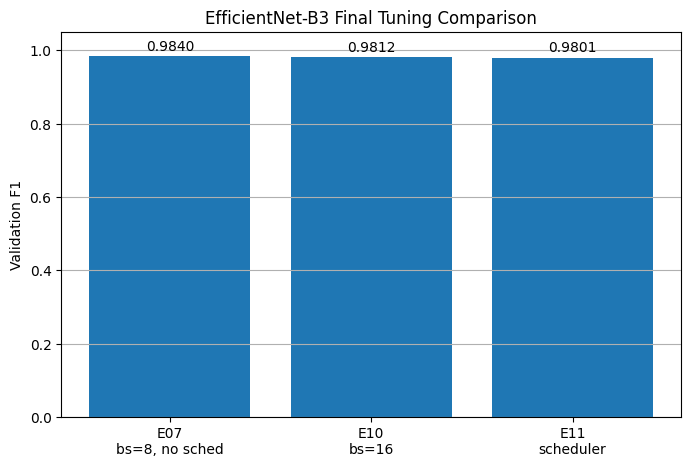

In [29]:
final_labels = ["E07\nbs=8, no sched", "E10\nbs=16", "E11\nscheduler"]
final_f1 = [0.983992, 0.981213, 0.980142]

plt.figure(figsize=(8, 5))
bars = plt.bar(final_labels, final_f1)
plt.ylabel("Validation F1")
plt.title("EfficientNet-B3 Final Tuning Comparison")
plt.ylim(0.0, 1.05)
plt.grid(True, axis="y")

for bar, value in zip(bars, final_f1):
    plt.text(bar.get_x() + bar.get_width()/2, value + 0.015, f"{value:.4f}", ha="center")

plt.savefig(plots_dir / "efficientnet_final_stage_comparison.png", bbox_inches="tight")
plt.show()

### EfficientNet-B3 Tuning Interpretation

EfficientNet-B3 improved substantially over the baseline during tuning. The best learning rate was 3e-4, AdamW outperformed both Adam and SGD, and weight decay of 1e-3 gave the strongest validation performance overall.

As with ResNet-50, light augmentation remained the best choice, while medium and strong augmentation caused severe performance collapse. Increasing batch size to 16 and adding a ReduceLROnPlateau scheduler did not improve over the best no-scheduler batch-size-8 configuration.

The best EfficientNet-B3 tuning run was E07.

## 22. Final Chosen Hyperparameters

The final EfficientNet-B3 configuration was selected based on the best validation F1-score across the tuning runs.

### 22.1 Final EfficientNet-B3 Configuration

In [30]:
final_config_df = pd.DataFrame([{
    "Model": "EfficientNet-B3",
    "Selected Run": "E07",
    "Optimizer": "AdamW",
    "Learning Rate": 3e-4,
    "Weight Decay": 1e-3,
    "Augmentation": "light",
    "Batch Size": 8,
    "Scheduler": "none",
    "Epochs": 10,
    "Patience": 3,
    "Best Val Loss": 0.041985,
    "Best Val Accuracy": 0.98395,
    "Best Val F1": 0.983992,
    "Best Val ROC-AUC": 0.998910,
    "Best Epoch": 10,
    "Checkpoint": "E07_best.pth",
}])

final_config_df

,Model,Selected Run,Optimizer,Learning Rate,Weight Decay,Augmentation,Batch Size,Scheduler,Epochs,Patience,Best Val Loss,Best Val Accuracy,Best Val F1,Best Val ROC-AUC,Best Epoch,Checkpoint
0,EfficientNet-B3,E07,AdamW,0.0003,0.001,light,8,none,10,3,0.041985,0.98395,0.983992,0.99891,10,E07_best.pth


### Final Configuration Interpretation

The final EfficientNet-B3 configuration used AdamW with a learning rate of 3e-4, weight decay of 1e-3, light augmentation, batch size 8, and no scheduler.

This configuration achieved the best validation F1-score during tuning and will be used for held-out test evaluation and external unseen-dataset evaluation.

In [31]:
final_config_path = results_dir / "efficientnet_final_config.csv"
final_config_df.to_csv(final_config_path, index=False)
print(f"Saved final configuration to {final_config_path}")

Saved final configuration to C:\Users\Richa\anaconda_projects\results\efficientnet_final_config.csv


## 23. Evaluate EfficientNet-B3 on Test Split

This section evaluates the final selected EfficientNet-B3 configuration on the held-out in-domain test split.

### 23.1 Test Dataloader

In [32]:
test_dataset = datasets.ImageFolder(test_dir, transform=val_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Classes:", test_dataset.classes)
print("Class to index:", test_dataset.class_to_idx)
print("Total test images:", len(test_dataset))

Classes: ['fake', 'real']
Class to index: {'fake': 0, 'real': 1}
Total test images: 20000


### 23.2 Load Best Checkpoint

In [33]:
best_checkpoint_path = checkpoints_dir / "E07_best.pth"

checkpoint = torch.load(best_checkpoint_path, map_location=device)

model = get_efficientnet_b3(num_classes=2)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

print("Loaded checkpoint:", best_checkpoint_path.name)
print("Best validation epoch:", checkpoint["epoch"])
print("Best validation F1:", checkpoint["best_val_f1"])
print("Model device:", next(model.parameters()).device)

Loaded checkpoint: E07_best.pth
Best validation epoch: 10
Best validation F1: 0.98399242008677
Model device: cuda:0


### 23.3 Evaluate on Test Split

In [34]:
criterion = nn.CrossEntropyLoss()
test_metrics = validate_one_epoch(model, test_loader, criterion, device)
test_metrics

{'accuracy': 0.9857,
 'precision': 0.9831874253879825,
 'recall': 0.9883,
 'f1': 0.985737083582685,
 'roc_auc': 0.9988832900000001,
 'loss': 0.040551006403889915}

### 23.4 Test Results Summary

In [35]:
test_results_df = pd.DataFrame([{
    "Model": "EfficientNet-B3",
    "Checkpoint": best_checkpoint_path.name,
    "Test Loss": test_metrics["loss"],
    "Test Accuracy": test_metrics["accuracy"],
    "Test Precision": test_metrics["precision"],
    "Test Recall": test_metrics["recall"],
    "Test F1": test_metrics["f1"],
    "Test ROC-AUC": test_metrics["roc_auc"],
}])

test_results_df

,Model,Checkpoint,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,EfficientNet-B3,E07_best.pth,0.040551,0.9857,0.983187,0.9883,0.985737,0.998883


### 23.5 Save Test Results

In [36]:
test_results_path = results_dir / "E07_test_results.csv"
test_results_df.to_csv(test_results_path, index=False)
print(f"Saved test results to {test_results_path}")

Saved test results to C:\Users\Richa\anaconda_projects\results\E07_test_results.csv


### EfficientNet-B3 Test Interpretation

The final tuned EfficientNet-B3 model achieved excellent performance on the held-out in-domain test split. Test accuracy reached 0.9857, while the F1-score reached 0.9857 and ROC-AUC reached 0.9989.

These results indicate that the selected EfficientNet-B3 configuration generalized very well within the original Kaggle dataset distribution. Compared with the final ResNet-50 test result, EfficientNet-B3 achieved stronger in-domain performance across the main evaluation metrics.

### 23.6 Test Confusion Matrix

<Figure size 600x600 with 0 Axes>

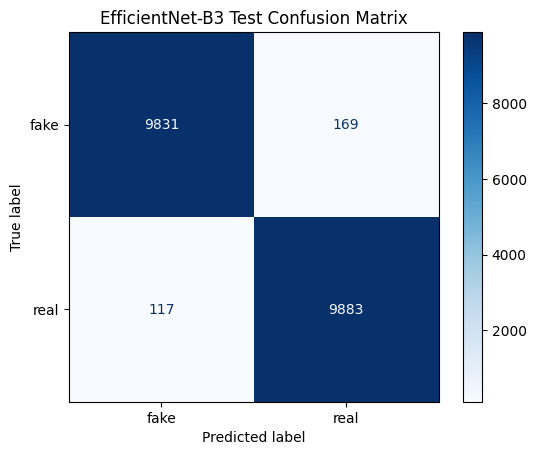

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=test_dataset.classes)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("EfficientNet-B3 Test Confusion Matrix")
plt.savefig(plots_dir / "E07_test_confusion_matrix.png", bbox_inches="tight")
plt.show()

### EfficientNet-B3 Test Confusion Matrix Interpretation

The confusion matrix shows that the final tuned EfficientNet-B3 model performed strongly on both classes in the held-out test split. It correctly classified 9,831 fake images and 9,883 real images, with only 169 fake images misclassified as real and 117 real images misclassified as fake.

This balanced pattern confirms that the model generalized well within the original dataset distribution and did not rely on predicting only one class. The low number of off-diagonal errors is consistent with the strong test accuracy, F1-score, and ROC-AUC values.

### 23.7 Test Metrics Bar Chart

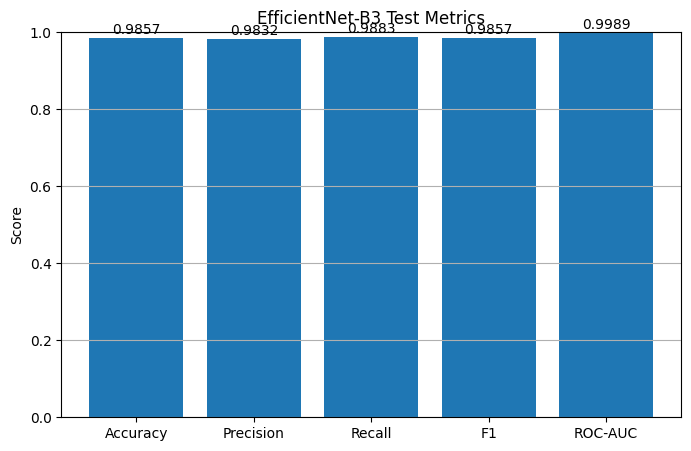

In [38]:
metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
metric_values = [
    test_metrics["accuracy"],
    test_metrics["precision"],
    test_metrics["recall"],
    test_metrics["f1"],
    test_metrics["roc_auc"],
]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values)
plt.ylabel("Score")
plt.title("EfficientNet-B3 Test Metrics")
plt.ylim(0.0, 1.0)
plt.grid(True, axis="y")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.savefig(plots_dir / "E07_test_metrics_bar_chart.png", bbox_inches="tight")
plt.show()

### EfficientNet-B3 Test Metrics Interpretation

This figure summarizes the final EfficientNet-B3 performance across the main binary classification metrics on the held-out test split. All metrics are very high, with accuracy and F1-score both around 0.986 and ROC-AUC close to 0.999.

Together with the confusion matrix, this confirms that the final EfficientNet-B3 configuration generalized strongly within the original dataset distribution and achieved balanced performance on both the fake and real classes.

The final EfficientNet-B3 model showed excellent in-domain test performance. The next step is to evaluate whether this strong performance transfers to unseen external datasets.

## 24. Evaluate EfficientNet-B3 on Unseen Dataset A

This section evaluates the final selected EfficientNet-B3 configuration on Unseen Dataset A, the external 130k Real vs Fake Face dataset.

This dataset was not used during training or hyperparameter tuning and is used only for cross-dataset evaluation.

### 24.1 Unseen Dataset A Path

In [39]:
unseen_a_root = Path.home() / "Desktop" / "130K" / "images"
print("Unseen A root:", unseen_a_root)

Unseen A root: C:\Users\Richa\Desktop\130K\images


### 24.2 Unseen A Dataloader

In [40]:
unseen_a_dataset = datasets.ImageFolder(unseen_a_root, transform=val_transform)

unseen_a_loader = DataLoader(
    unseen_a_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Classes:", unseen_a_dataset.classes)
print("Class to index:", unseen_a_dataset.class_to_idx)
print("Total images:", len(unseen_a_dataset))

Classes: ['fake', 'real']
Class to index: {'fake': 0, 'real': 1}
Total images: 133569


### 24.3 Load Best Checkpoint

In [41]:
best_checkpoint_path = checkpoints_dir / "E07_best.pth"

checkpoint = torch.load(best_checkpoint_path, map_location=device)

model = get_efficientnet_b3(num_classes=2)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

print("Loaded checkpoint:", best_checkpoint_path.name)
print("Best validation epoch:", checkpoint["epoch"])
print("Best validation F1:", checkpoint["best_val_f1"])
print("Model device:", next(model.parameters()).device)

Loaded checkpoint: E07_best.pth
Best validation epoch: 10
Best validation F1: 0.98399242008677
Model device: cuda:0


### 24.4 Evaluate on Unseen Dataset A

In [42]:
criterion = nn.CrossEntropyLoss()
unseen_a_metrics = validate_one_epoch(model, unseen_a_loader, criterion, device)
unseen_a_metrics

{'accuracy': 0.5201057131520038,
 'precision': 0.5221883812746757,
 'recall': 0.9919714285714286,
 'f1': 0.6842024879911319,
 'roc_auc': 0.4065413478717164,
 'loss': 3.7338264048031364}

### 24.5 Unseen A Results Summary

In [43]:
unseen_a_results_df = pd.DataFrame([{
    "Model": "EfficientNet-B3",
    "Checkpoint": best_checkpoint_path.name,
    "Dataset": "130K Real vs Fake Face",
    "Unseen Loss": unseen_a_metrics["loss"],
    "Unseen Accuracy": unseen_a_metrics["accuracy"],
    "Unseen Precision": unseen_a_metrics["precision"],
    "Unseen Recall": unseen_a_metrics["recall"],
    "Unseen F1": unseen_a_metrics["f1"],
    "Unseen ROC-AUC": unseen_a_metrics["roc_auc"],
}])

unseen_a_results_df

,Model,Checkpoint,Dataset,Unseen Loss,Unseen Accuracy,Unseen Precision,Unseen Recall,Unseen F1,Unseen ROC-AUC
0,EfficientNet-B3,E07_best.pth,130K Real vs Fake Face,3.733826,0.520106,0.522188,0.991971,0.684202,0.406541


### EfficientNet-B3 Unseen Dataset A Interpretation

The final EfficientNet-B3 model showed a large performance drop on Unseen Dataset A compared with the held-out in-domain test split. Although the model achieved excellent in-domain test performance, cross-dataset performance was much weaker on the external 130k Real vs Fake Face dataset.

Accuracy remained close to chance level and ROC-AUC dropped sharply, while recall stayed very high. This metric pattern suggests that the model predicted the real class for most samples in the unseen dataset. These results indicate strong domain shift between the original training distribution and the external dataset, and show that the stronger in-domain performance of EfficientNet-B3 did not translate into better external generalization.

### 24.6 Save Unseen A Results

In [44]:
unseen_a_results_path = results_dir / "E07_unseen_a_results.csv"
unseen_a_results_df.to_csv(unseen_a_results_path, index=False)
print(f"Saved unseen A results to {unseen_a_results_path}")

Saved unseen A results to C:\Users\Richa\anaconda_projects\results\E07_unseen_a_results.csv


### 24.7 Unseen A Confusion Matrix

<Figure size 600x600 with 0 Axes>

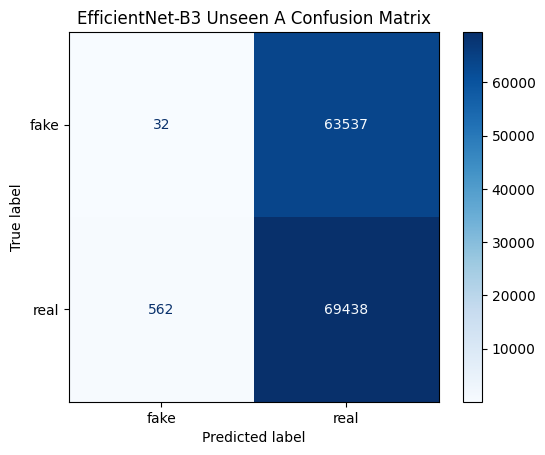

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in unseen_a_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unseen_a_dataset.classes)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("EfficientNet-B3 Unseen A Confusion Matrix")
plt.savefig(plots_dir / "E07_unseen_a_confusion_matrix.png", bbox_inches="tight")
plt.show()

### 24.8 Unseen A Metrics Bar Chart

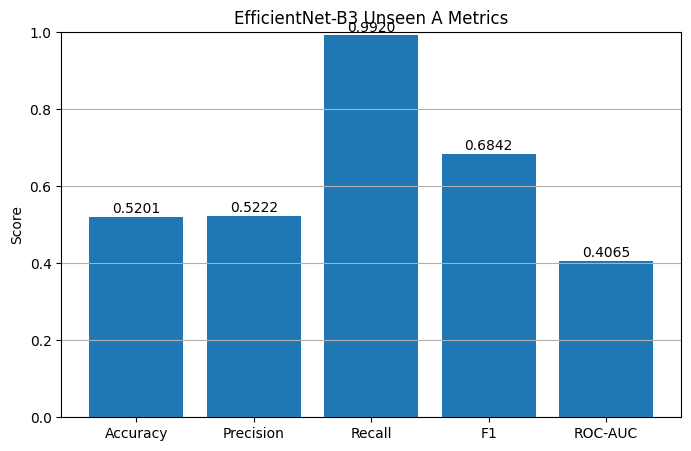

In [46]:
metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
metric_values = [
    unseen_a_metrics["accuracy"],
    unseen_a_metrics["precision"],
    unseen_a_metrics["recall"],
    unseen_a_metrics["f1"],
    unseen_a_metrics["roc_auc"],
]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values)
plt.ylabel("Score")
plt.title("EfficientNet-B3 Unseen A Metrics")
plt.ylim(0.0, 1.0)
plt.grid(True, axis="y")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.savefig(plots_dir / "E07_unseen_a_metrics_bar_chart.png", bbox_inches="tight")
plt.show()

### EfficientNet-B3 Unseen Dataset A Interpretation

The confusion matrix shows that the final EfficientNet-B3 model predicted almost all samples in Unseen Dataset A as real. Only 32 fake images were correctly classified as fake, while 63,537 fake images were incorrectly classified as real.

This explains the observed metric pattern: recall remained very high because the model correctly identified most real images, but overall accuracy and ROC-AUC were poor because the fake class was not separated effectively. These results indicate strong domain shift between the original training distribution and the external 130k Real vs Fake Face dataset.

Although EfficientNet-B3 achieved stronger in-domain test performance than ResNet-50, it did not show better external generalization on Unseen Dataset A. This suggests that improved in-domain accuracy did not translate into more robust cross-dataset fake-face detection.

## 25. Evaluate EfficientNet-B3 on Unseen Dataset B

This section evaluates the final selected EfficientNet-B3 configuration on Unseen Dataset B, a smaller deepfake-vs-real external image benchmark.

This dataset was not used during training or hyperparameter tuning and is used only for cross-dataset evaluation.

### 25.1 Unseen Dataset B Path

In [47]:
unseen_b_root = Path.home() / "Desktop" / "Deepfake_vs_Real_eval"
print("Unseen B root:", unseen_b_root)

Unseen B root: C:\Users\Richa\Desktop\Deepfake_vs_Real_eval


### 25.2 Unseen B Dataloader

In [48]:
unseen_b_dataset = datasets.ImageFolder(unseen_b_root, transform=val_transform)

unseen_b_loader = DataLoader(
    unseen_b_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

print("Classes:", unseen_b_dataset.classes)
print("Class to index:", unseen_b_dataset.class_to_idx)
print("Total images:", len(unseen_b_dataset))

Classes: ['fake', 'real']
Class to index: {'fake': 0, 'real': 1}
Total images: 8000


### 25.3 Load Best Checkpoint

In [49]:
best_checkpoint_path = checkpoints_dir / "E07_best.pth"

checkpoint = torch.load(best_checkpoint_path, map_location=device)

model = get_efficientnet_b3(num_classes=2)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)

print("Loaded checkpoint:", best_checkpoint_path.name)
print("Best validation epoch:", checkpoint["epoch"])
print("Best validation F1:", checkpoint["best_val_f1"])
print("Model device:", next(model.parameters()).device)

Loaded checkpoint: E07_best.pth
Best validation epoch: 10
Best validation F1: 0.98399242008677
Model device: cuda:0


### 25.4 Evaluate on Unseen Dataset B

In [50]:
criterion = nn.CrossEntropyLoss()
unseen_b_metrics = validate_one_epoch(model, unseen_b_loader, criterion, device)
unseen_b_metrics

{'accuracy': 0.483875,
 'precision': 0.4917928489629724,
 'recall': 0.96625,
 'f1': 0.6518256176743402,
 'roc_auc': 0.3065540625,
 'loss': 3.926518075314729}

### 25.5 Unseen B Results Summary

In [51]:
unseen_b_results_df = pd.DataFrame([{
    "Model": "EfficientNet-B3",
    "Checkpoint": best_checkpoint_path.name,
    "Dataset": "Deepfake-vs-Real",
    "Unseen Loss": unseen_b_metrics["loss"],
    "Unseen Accuracy": unseen_b_metrics["accuracy"],
    "Unseen Precision": unseen_b_metrics["precision"],
    "Unseen Recall": unseen_b_metrics["recall"],
    "Unseen F1": unseen_b_metrics["f1"],
    "Unseen ROC-AUC": unseen_b_metrics["roc_auc"],
}])

unseen_b_results_df

,Model,Checkpoint,Dataset,Unseen Loss,Unseen Accuracy,Unseen Precision,Unseen Recall,Unseen F1,Unseen ROC-AUC
0,EfficientNet-B3,E07_best.pth,Deepfake-vs-Real,3.926518,0.483875,0.491793,0.96625,0.651826,0.306554


### 25.6 Save Unseen B Results

In [52]:
unseen_b_results_path = results_dir / "E07_unseen_b_results.csv"
unseen_b_results_df.to_csv(unseen_b_results_path, index=False)
print(f"Saved unseen B results to {unseen_b_results_path}")

Saved unseen B results to C:\Users\Richa\anaconda_projects\results\E07_unseen_b_results.csv


### 25.7 Unseen B Confusion Matrix

<Figure size 600x600 with 0 Axes>

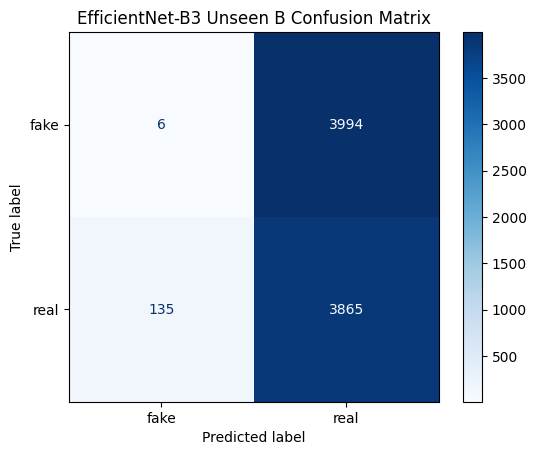

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for images, labels in unseen_b_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=unseen_b_dataset.classes)

plt.figure(figsize=(6, 6))
disp.plot(cmap="Blues", values_format="d")
plt.title("EfficientNet-B3 Unseen B Confusion Matrix")
plt.savefig(plots_dir / "E07_unseen_b_confusion_matrix.png", bbox_inches="tight")
plt.show()

### 25.8 Unseen B Metrics Bar Chart

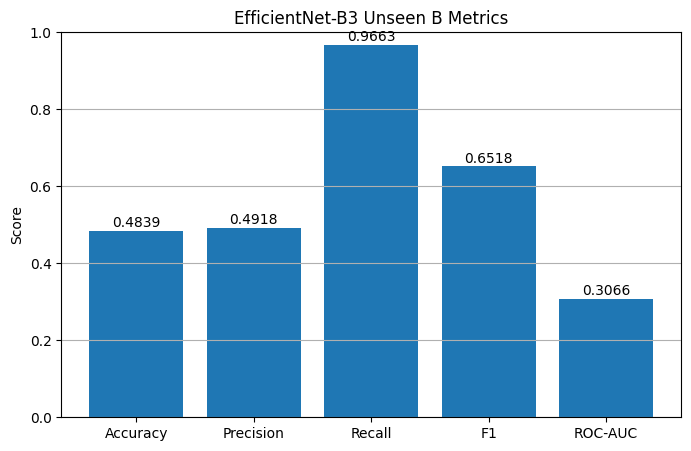

In [54]:
metric_names = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
metric_values = [
    unseen_b_metrics["accuracy"],
    unseen_b_metrics["precision"],
    unseen_b_metrics["recall"],
    unseen_b_metrics["f1"],
    unseen_b_metrics["roc_auc"],
]

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values)
plt.ylabel("Score")
plt.title("EfficientNet-B3 Unseen B Metrics")
plt.ylim(0.0, 1.0)
plt.grid(True, axis="y")

for bar, value in zip(bars, metric_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )

plt.savefig(plots_dir / "E07_unseen_b_metrics_bar_chart.png", bbox_inches="tight")
plt.show()

### EfficientNet-B3 Unseen Dataset B Interpretation

The confusion matrix shows that the final EfficientNet-B3 model predicted the real class for almost all samples in Unseen Dataset B. Only 6 fake images were correctly classified as fake, while 3,994 fake images were incorrectly classified as real.

This explains the weak metric pattern observed on Unseen Dataset B. Although recall remained high, overall accuracy dropped below 0.50 and ROC-AUC fell to approximately 0.31, indicating very poor class separation on this external deepfake benchmark.

Together with the weak Unseen Dataset A result, this shows that the strong in-domain test performance of EfficientNet-B3 did not translate into robust external generalization. Both CNN architectures performed well on the original dataset distribution but failed substantially on unseen external datasets.

## 26. Final Model Comparison

This section compares the final selected ResNet-50 and EfficientNet-B3 configurations across the held-out in-domain test split and both unseen external datasets.

The goal is to summarize which model performed better in-domain and whether either model generalized more effectively across datasets.

### 26.1 Final Comparison Table

In [2]:
# Path setup for final comparison
# Allows this section to run even if the earlier project-path cell was not rerun.
from pathlib import Path
import pandas as pd
import numpy as np

project_root = Path.cwd()
results_dir = project_root / "results"

# If the notebook is launched from a subfolder, fall back to the parent results folder.
if not results_dir.exists() and (project_root.parent / "results").exists():
    results_dir = project_root.parent / "results"

print("Using results directory:", results_dir)

# ResNet-50 values are pulled from the corrected R13 result files when available.
# This keeps the EfficientNet notebook consistent with the updated ResNet final model.

resnet_test_path = results_dir / "R13_test_results.csv"
resnet_unseen_a_path = results_dir / "R13_unseen_a_results.csv"
resnet_unseen_b_path = results_dir / "R13_unseen_b_results.csv"

if resnet_test_path.exists():
    resnet_test_df = pd.read_csv(resnet_test_path)
    resnet_test_accuracy = float(resnet_test_df.loc[0, "Test Accuracy"])
    resnet_test_f1 = float(resnet_test_df.loc[0, "Test F1"])
    resnet_test_roc_auc = float(resnet_test_df.loc[0, "Test ROC-AUC"])
else:
    # Fallback values based on the corrected R13 confusion matrix/known results.
    # Re-run the ResNet final evaluation and save R13_test_results.csv for exact ROC-AUC.
    resnet_test_accuracy = 0.9786
    resnet_test_f1 = 0.9786
    resnet_test_roc_auc = np.nan

if resnet_unseen_a_path.exists():
    resnet_unseen_a_df = pd.read_csv(resnet_unseen_a_path)
    resnet_unseen_a_accuracy = float(resnet_unseen_a_df.loc[0, "Unseen Accuracy"])
    resnet_unseen_a_f1 = float(resnet_unseen_a_df.loc[0, "Unseen F1"])
    resnet_unseen_a_roc_auc = float(resnet_unseen_a_df.loc[0, "Unseen ROC-AUC"])
else:
    resnet_unseen_a_accuracy = 0.5195
    resnet_unseen_a_f1 = 0.6837
    resnet_unseen_a_roc_auc = 0.5732

if resnet_unseen_b_path.exists():
    resnet_unseen_b_df = pd.read_csv(resnet_unseen_b_path)
    resnet_unseen_b_accuracy = float(resnet_unseen_b_df.loc[0, "Unseen Accuracy"])
    resnet_unseen_b_f1 = float(resnet_unseen_b_df.loc[0, "Unseen F1"])
    resnet_unseen_b_roc_auc = float(resnet_unseen_b_df.loc[0, "Unseen ROC-AUC"])
else:
    resnet_unseen_b_accuracy = 0.4930
    resnet_unseen_b_f1 = 0.660415
    resnet_unseen_b_roc_auc = 0.618770

final_model_comparison_df = pd.DataFrame([
    {
        "Model": "ResNet-50",
        "Selected Run": "R13",
        "Test Accuracy": resnet_test_accuracy,
        "Test F1": resnet_test_f1,
        "Test ROC-AUC": resnet_test_roc_auc,
        "Unseen A Accuracy": resnet_unseen_a_accuracy,
        "Unseen A F1": resnet_unseen_a_f1,
        "Unseen A ROC-AUC": resnet_unseen_a_roc_auc,
        "Unseen B Accuracy": resnet_unseen_b_accuracy,
        "Unseen B F1": resnet_unseen_b_f1,
        "Unseen B ROC-AUC": resnet_unseen_b_roc_auc,
    },
    {
        "Model": "EfficientNet-B3",
        "Selected Run": "E07",
        "Test Accuracy": 0.9857,
        "Test F1": 0.985737,
        "Test ROC-AUC": 0.998883,
        "Unseen A Accuracy": 0.520106,
        "Unseen A F1": 0.684202,
        "Unseen A ROC-AUC": 0.406541,
        "Unseen B Accuracy": 0.483875,
        "Unseen B F1": 0.651826,
        "Unseen B ROC-AUC": 0.306554,
    },
])

final_model_comparison_df

Using results directory: C:\Users\Richa\anaconda_projects\results


,Model,Selected Run,Test Accuracy,Test F1,Test ROC-AUC,Unseen A Accuracy,Unseen A F1,Unseen A ROC-AUC,Unseen B Accuracy,Unseen B F1,Unseen B ROC-AUC
0,ResNet-50,R13,0.9786,0.978615,0.997985,0.519454,0.683722,0.573175,0.493000,0.660415,0.618770
1,EfficientNet-B3,E07,0.9857,0.985737,0.998883,0.520106,0.684202,0.406541,0.483875,0.651826,0.306554


### 26.2 Held-Out Test Split Comparison

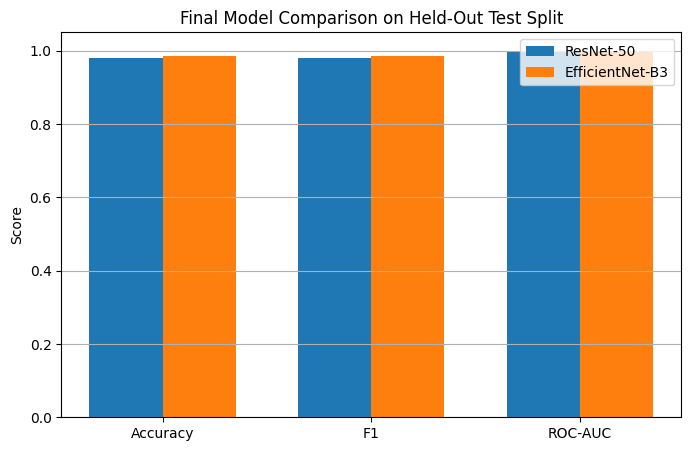

In [6]:
test_labels = ["Accuracy", "F1", "ROC-AUC"]
resnet_test = [resnet_test_accuracy, resnet_test_f1, resnet_test_roc_auc]
efficientnet_test = [0.9857, 0.985737, 0.998883]

x = np.arange(len(test_labels))
width = 0.35

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, resnet_test, width, label="ResNet-50")
plt.bar(x + width/2, efficientnet_test, width, label="EfficientNet-B3")

plt.xticks(x, test_labels)
plt.ylabel("Score")
plt.title("Final Model Comparison on Held-Out Test Split")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True, axis="y")
plt.savefig(plots_dir / "final_model_test_comparison.png", bbox_inches="tight")
plt.show()

### 26.3 Unseen Dataset A Comparison

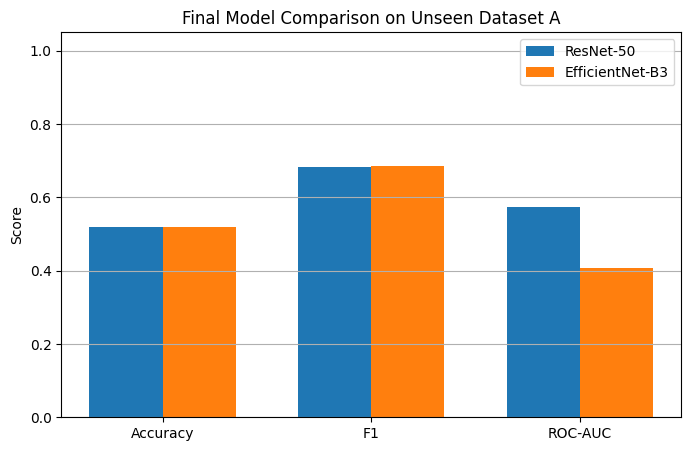

In [7]:
unseen_a_labels = ["Accuracy", "F1", "ROC-AUC"]
resnet_unseen_a = [resnet_unseen_a_accuracy, resnet_unseen_a_f1, resnet_unseen_a_roc_auc]
efficientnet_unseen_a = [0.520106, 0.684202, 0.406541]

x = np.arange(len(unseen_a_labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, resnet_unseen_a, width, label="ResNet-50")
plt.bar(x + width/2, efficientnet_unseen_a, width, label="EfficientNet-B3")

plt.xticks(x, unseen_a_labels)
plt.ylabel("Score")
plt.title("Final Model Comparison on Unseen Dataset A")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True, axis="y")
plt.savefig(plots_dir / "final_model_unseen_a_comparison.png", bbox_inches="tight")
plt.show()

### 26.4 Unseen Dataset B Comparison

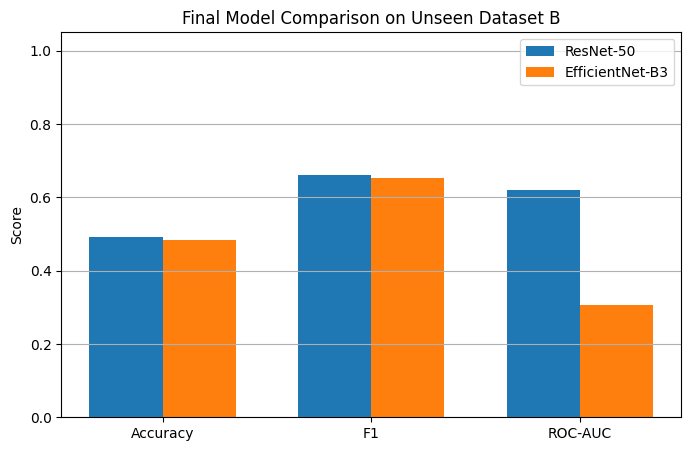

In [8]:
unseen_b_labels = ["Accuracy", "F1", "ROC-AUC"]
resnet_unseen_b = [resnet_unseen_b_accuracy, resnet_unseen_b_f1, resnet_unseen_b_roc_auc]
efficientnet_unseen_b = [0.483875, 0.651826, 0.306554]

x = np.arange(len(unseen_b_labels))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, resnet_unseen_b, width, label="ResNet-50")
plt.bar(x + width/2, efficientnet_unseen_b, width, label="EfficientNet-B3")

plt.xticks(x, unseen_b_labels)
plt.ylabel("Score")
plt.title("Final Model Comparison on Unseen Dataset B")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True, axis="y")
plt.savefig(plots_dir / "final_model_unseen_b_comparison.png", bbox_inches="tight")
plt.show()

### 26.5 Overall F1 Comparison Across Evaluation Sets

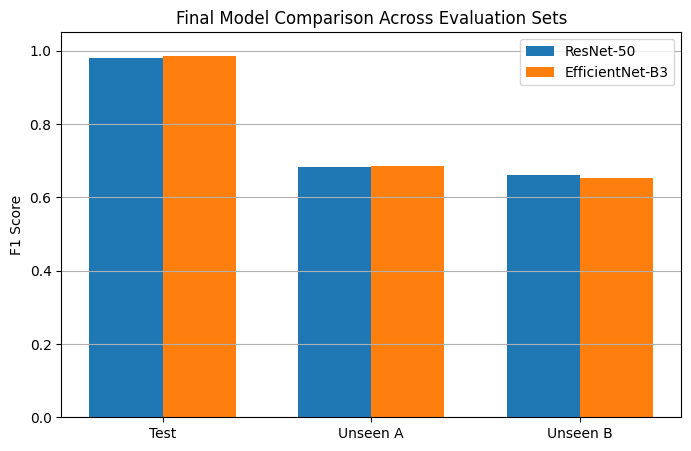

In [9]:
eval_sets = ["Test", "Unseen A", "Unseen B"]
resnet_f1 = [resnet_test_f1, resnet_unseen_a_f1, resnet_unseen_b_f1]
efficientnet_f1 = [0.985737, 0.684202, 0.651826]

x = np.arange(len(eval_sets))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, resnet_f1, width, label="ResNet-50")
plt.bar(x + width/2, efficientnet_f1, width, label="EfficientNet-B3")

plt.xticks(x, eval_sets)
plt.ylabel("F1 Score")
plt.title("Final Model Comparison Across Evaluation Sets")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True, axis="y")
plt.savefig(plots_dir / "final_model_f1_across_evaluation_sets.png", bbox_inches="tight")
plt.show()

### Final Model Comparison Interpretation

EfficientNet-B3 achieved the strongest in-domain performance on the held-out test split, with slightly higher accuracy, F1-score, and ROC-AUC than the corrected final ResNet-50 R13 model. This indicates that EfficientNet-B3 was the better model within the original Kaggle dataset distribution.

However, the external unseen-dataset results show a more mixed pattern. On Unseen Dataset A, both models performed poorly and showed evidence of strong real-class prediction bias. EfficientNet-B3 achieved a slightly higher F1-score, while ResNet-50 R13 achieved a higher ROC-AUC, suggesting somewhat better class separation despite weak overall accuracy.

On Unseen Dataset B, ResNet-50 R13 outperformed EfficientNet-B3 on F1-score and ROC-AUC, but both models still performed close to chance-level accuracy. This shows that neither model generalized reliably to the external deepfake benchmark.

Overall, EfficientNet-B3 was the stronger in-domain model, while ResNet-50 R13 showed somewhat better external ranking performance on the unseen datasets. The main finding remains that high in-domain test performance did not translate into robust cross-dataset generalization for either CNN architecture.

In [10]:
final_model_comparison_path = results_dir / "final_model_comparison.csv"
final_model_comparison_df.to_csv(final_model_comparison_path, index=False)
print(f"Saved final model comparison to {final_model_comparison_path}")

Saved final model comparison to C:\Users\Richa\anaconda_projects\results\final_model_comparison.csv


## 27. Final Conclusion

This section summarizes the main findings of the project and highlights the overall conclusions from the ResNet-50 and EfficientNet-B3 experiments.

## Final Conclusion

This project evaluated two CNN architectures, ResNet-50 and EfficientNet-B3, for binary classification of real versus fake face images. Both models were trained from scratch on the Kaggle 140k Real and Fake Faces dataset and tuned through a sequence of controlled hyperparameter experiments.

EfficientNet-B3 achieved the strongest held-out in-domain test performance. It slightly outperformed the corrected final ResNet-50 R13 model across the main test metrics, including accuracy, F1-score, and ROC-AUC. This suggests that EfficientNet-B3 learned the original Kaggle dataset distribution more effectively.

However, the unseen external dataset evaluations revealed a different pattern. Both models showed large performance drops on Unseen Dataset A and Unseen Dataset B, indicating weak cross-dataset generalization. The confusion matrices showed that both models developed a strong bias toward predicting the real class on external datasets, which caused poor fake-image detection despite high recall for real images.

The corrected ResNet-50 R13 model improved over the earlier ResNet result and achieved better ROC-AUC than EfficientNet-B3 on both unseen datasets. It also performed better than EfficientNet-B3 on Unseen Dataset B F1-score. Even so, its unseen accuracy remained close to chance level, showing that the improvement was not enough to solve the broader generalization problem.

Overall, the results suggest that the main challenge in real-versus-fake face classification is not only achieving high accuracy on a single dataset, but learning features that remain reliable across different fake-image sources and external data distributions. The project highlights the importance of cross-dataset evaluation when assessing deep learning models for fake-face detection.

### Closing Statement

In summary, EfficientNet-B3 was the stronger in-domain model, while ResNet-50 R13 showed somewhat better external ROC-AUC on the unseen datasets. However, neither CNN architecture generalized reliably to external datasets, suggesting that domain shift and reliance on dataset-specific cues remain major challenges for robust fake-face detection.

The experiment logs, saved checkpoints, result tables, and plots generated in this project provide a complete record of the training, tuning, and evaluation workflow for both architectures.